### Stage 04 Selection & Pareto Efficiency Analysis

Analyze and compare topic model optimization results from **Stage03** (single or multiple embedding runs). Default config: **v4 granular three-way compare** (L12 / L6 / MPNet Phase 1, 160 BO calls each).

- **Three selection strategies (per run):**  
  - *Legacy equal weights (50/50)*
  - *Coherence-priority (70/30)*
  - *Current eval_select granular (45/20/+15 floor/−10/−10)*
- **Pooled cross-embedding Pareto** over all runs combined (section 10)
- **Phase 2 Pareto refit merge** — stability flags + compare-fit vs BO-reported metrics (section 11)

Set `NB_CONFIG` in the setup cell (defaults to `configs/stage04/selection_notebooks_v4_granular.yaml`). Per-run outputs go to `results/selection/{run_id}/notebook_analysis/`; cross-model comparison artifacts go to `comparison.base_dir`.


In [1]:
# --- 0. Setup (run this cell first) ---
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.common.config import load_config, resolve_path
from src.legacy.stage04_selection.trials_profile import SUMMARY_SECTIONS, summarize_trials_by_role
from src.stage04_eval_select.notebook_io import (
    LEGACY_RENAME,
    STRATEGY_FILES,
    analyze_pareto_efficiency,
    apply_selection_filters,
    calculate_combined_score,
    compare_metric_snapshot_by_run,
    ensure_run_dirs,
    filter_trials_by_run,
    identify_pareto,
    load_phase2_results,
    load_trials_for_runs,
    metric_snapshot,
    normalize_for_pareto,
    normalize_for_pareto_pooled,
    normalize_metrics,
    normalize_trials_partial_df,
    resolve_comparison_dirs,
    resolve_run_dirs,
    resolve_runs,
)
from src.stage04_eval_select.weighted_score import apply_weighted_score

METRIC_COLS = ("Coherence", "Topic_Diversity", "n_topics")

# Notebook config: v4 granular three-way compare by default.
# For the legacy v3 L12-vs-L6 compare use configs/stage04/selection_notebooks.yaml.
NB_CONFIG = "configs/stage04/selection_notebooks_v4_granular.yaml"

nb_cfg = load_config(project_root / NB_CONFIG)
eval_cfg = load_config(resolve_path(Path(nb_cfg["eval_select_config"]), project_root))
runs = resolve_runs(nb_cfg)
run_dirs = {run["run_id"]: resolve_run_dirs(run, project_root) for run in runs}
for dirs in run_dirs.values():
    ensure_run_dirs(dirs)

cmp_dirs = resolve_comparison_dirs(nb_cfg, project_root)
multi_run = len(runs) > 1

primary_run = runs[0]
figures_dir = run_dirs[primary_run["run_id"]]["figures_dir"]
tables_dir = run_dirs[primary_run["run_id"]]["tables_dir"]
top_models_dir = run_dirs[primary_run["run_id"]]["top_models_dir"]

sns.set_style(nb_cfg.get("plotting", {}).get("style", "whitegrid"))
plt.rcParams["figure.dpi"] = nb_cfg.get("plotting", {}).get("figure_dpi", 100)
TOP_K = int(nb_cfg["selection"]["top_k"])
PARETO_METRICS = nb_cfg["pareto"]["metrics"]
sel = eval_cfg["selection"]

df_raw = load_trials_for_runs(runs, project_root)
print(f"Project root: {project_root}")
print(f"Runs: {[r['run_id'] for r in runs]} ({'compare' if multi_run else 'single'} mode)")
print(f"Loaded {len(df_raw)} trials × {df_raw.shape[1]} columns")


def cleaning_funnel(steps):
    return pd.DataFrame(steps, columns=["step", "removed", "remaining"])


Project root: /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Runs: ['v4_l12_granular_phase1_dryrun', 'v4_l6_granular_phase1_dryrun', 'v4_mpnet_granular_phase1_dryrun'] (compare mode)
Loaded 480 trials × 34 columns


## 1. Trial overview

Type-aware profile of `df_raw` (loaded in setup). Partial BO rows omit `coherence_c_npmi` / `outlier_rate` (computed later in Stage05 / final `trials.csv`).

In [2]:
# Columns added by load_trials_for_runs that the legacy profiler does not know about.
_NB_ADDED_COLS = ["model_label", "Embeddings_Model"]

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    subset = df_raw[df_raw["run_id"] == rid].drop(columns=_NB_ADDED_COLS, errors="ignore")
    print(f"\n{'=' * 60}\nTrial overview — {label} ({rid})\n{'=' * 60}")
    trials_summaries = summarize_trials_by_role(subset)
    for key, title in SUMMARY_SECTIONS:
        if key in trials_summaries:
            print(f"=== {title} ===")
            display(trials_summaries[key])

if multi_run:
    print("\n=== Cross-run summary (raw trials) ===")
    cross = (
        df_raw.groupby(["run_id", "model_label"])
        .agg(
            n_trials=("trial_id", "count"),
            coherence_max=("coherence_c_v", "max"),
            coherence_median=("coherence_c_v", "median"),
            diversity_median=("topic_diversity", "median"),
            stability_pass_pct=("topic_stability_pass", lambda s: float(s.mean()) if len(s) else np.nan),
        )
        .reset_index()
    )
    display(cross)
    if cmp_dirs:
        cross.to_csv(cmp_dirs["tables_dir"] / "compare_run_summary_raw.csv", index=False)

print("\n=== First rows (all runs) ===")
display(df_raw.head())



Trial overview — v4_L12 (v4_l12_granular_phase1_dryrun)
=== Column schema (all variables) ===


,column,role,presentation,dtype,non_null,missing_pct,n_unique
0,run_id,identifier,Unique count and example value (no mean/std).,object,160,0.0,1
1,trial_id,identifier,Unique count and example value (no mean/std).,object,160,0.0,160
2,bo_call,bo_index,BO iteration index: range and sequential check...,int64,160,0.0,160
3,seed,run_constant,Single value shared by all trials in a run.,int64,160,0.0,1
9,stability_score,run_constant,Single value shared by all trials in a run.,float64,160,0.0,1
4,embedding_model,categorical,Value counts for each level.,object,160,0.0,1
26,hdbscan__cluster_selection_method,categorical,Value counts for each level.,object,160,0.0,1
11,eval_csv,path,Unique path count and one example (paths are m...,object,160,0.0,1
12,test_csv,path,Unique path count and one example (paths are m...,object,160,0.0,1
10,train_csv,path,Unique path count and one example (paths are m...,object,160,0.0,1


=== Identifiers ===


,column,non_null,n_unique,example
0,run_id,160,1,v4_l12_granular_phase1_dryrun
1,trial_id,160,160,v4_l12_granular_phase1_1_call_0


=== BO iteration index (not a metric) ===


...

,column,non_null,missing_pct,mean,std,min,p25,median,p75,max
0,bertopic__top_n_words,160,0.0,32.775000,8.127096,20.000000,26.000000,31.000000,39.00000,49.00000
1,hdbscan__min_cluster_size,160,0.0,180.293750,76.972559,25.000000,136.750000,165.000000,198.00000,350.00000
2,hdbscan__min_samples,160,0.0,30.231250,10.042815,5.000000,24.000000,31.000000,38.00000,45.00000
3,umap__min_dist,160,0.0,0.082708,0.032538,0.000823,0.063253,0.091961,0.11174,0.11994
4,umap__n_components,160,0.0,15.312500,3.997149,5.000000,13.000000,16.000000,19.00000,20.00000
5,umap__n_neighbors,160,0.0,12.506250,7.363002,5.000000,8.000000,11.000000,13.00000,43.00000
6,vectorizer__min_df,160,0.0,10.481250,5.402040,3.000000,6.000000,9.000000,14.00000,25.00000



=== Cross-run summary (raw trials) ===


,run_id,model_label,n_trials,coherence_max,coherence_median,diversity_median,stability_pass_pct
0,v4_l12_granular_phase1_dryrun,v4_L12,160,0.694065,0.614570,0.715357,1.0
1,v4_l6_granular_phase1_dryrun,v4_L6,160,0.704220,0.691787,0.268953,1.0
2,v4_mpnet_granular_phase1_dryrun,v4_MPNet,160,0.794639,0.625768,0.688470,1.0



=== First rows (all runs) ===


,run_id,trial_id,bo_call,seed,embedding_model,coherence_c_v,bo_objective,topic_diversity,n_topics,stability_score,...,topic_stability_pass,bertopic__top_n_words,hdbscan__cluster_selection_method,hdbscan__min_cluster_size,hdbscan__min_samples,umap__min_dist,umap__n_components,umap__n_neighbors,vectorizer__min_df,model_label
0,v4_l12_granular_phase1_dryrun,v4_l12_granular_phase1_1_call_0,0,42,sentence-transformers/all-MiniLM-L12-v2,0.595833,0.595833,0.898058,412.0,0.0,...,True,34,eom,94,18,0.058222,9,13,7,v4_L12
1,v4_l12_granular_phase1_dryrun,v4_l12_granular_phase1_1_call_1,1,42,sentence-transformers/all-MiniLM-L12-v2,0.589770,0.301770,1.000000,2.0,0.0,...,True,39,eom,157,36,0.034351,17,16,10,v4_L12
2,v4_l12_granular_phase1_dryrun,v4_l12_granular_phase1_1_call_2,2,42,sentence-transformers/all-MiniLM-L12-v2,0.623145,0.335145,1.000000,2.0,0.0,...,True,48,eom,123,22,0.063613,6,34,22,v4_L12
3,v4_l12_granular_phase1_dryrun,v4_l12_granular_phase1_1_call_3,3,42,sentence-transformers/all-MiniLM-L12-v2,0.602758,0.320758,1.000000,3.0,0.0,...,True,28,eom,117,29,0.065571,20,16,17,v4_L12
4,v4_l12_granular_phase1_dryrun,v4_l12_granular_phase1_1_call_4,4,42,sentence-transformers/all-MiniLM-L12-v2,0.560164,0.272164,1.000000,2.0,0.0,...,True,47,eom,307,27,0.042625,10,30,4,v4_L12


## 2. Selection filters

Same row filters, in the same order, as `src.stage04_eval_select.cli select` with the config from `eval_select_config` (granular gates: `min_n_topics`, `max_n_topics`, `max_outlier_rate`, `max_largest_topic_share`, stability). All three ranking strategies below share this filtered trial set — no legacy 2σ outlier cleaning.

In [3]:
filtered_by_run, df_trials, funnel_df = filter_trials_by_run(df_raw, runs, sel)

print(f"Selection filters ({nb_cfg['eval_select_config']}) — per run")
for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    sub = funnel_df[funnel_df["run_id"] == rid][["step", "removed", "remaining"]]
    print(f"\n--- {label} ({rid}) ---")
    display(sub)
    renamed = filtered_by_run[rid].rename(columns=LEGACY_RENAME)
    display(metric_snapshot(renamed))

if cmp_dirs:
    funnel_df.to_csv(cmp_dirs["tables_dir"] / "selection_funnel_by_run.csv", index=False)
    compare_snap = compare_metric_snapshot_by_run(df_raw, filtered_by_run, runs)
    compare_snap.to_csv(cmp_dirs["tables_dir"] / "compare_metric_snapshot.csv", index=False)
    print(f"\nSaved comparison tables under {cmp_dirs['tables_dir']}")


Selection filters (configs/stage04/eval_select_granular.yaml) — per run

--- v4_L12 (v4_l12_granular_phase1_dryrun) ---


,step,removed,remaining
0,loaded,0,160
1,n_topics >= 50,45,115
2,n_topics <= 800,0,115
3,outlier_rate <= 0.85,0,115
4,largest_topic_share <= 0.25,0,115
5,n_topics_std <= 75.0,0,115


,n,median,q25,q75,min,max
metric,,,,,,
Coherence,115,0.6218,0.6076,0.6345,0.5106,0.6941
Topic_Diversity,115,0.6172,0.5109,0.7639,0.2739,0.9672
n_topics,115,395.0000,360.0000,426.5000,117.0000,505.0000



--- v4_L6 (v4_l6_granular_phase1_dryrun) ---


,step,removed,remaining
6,loaded,0,160
7,n_topics >= 50,6,154
8,n_topics <= 800,0,154
9,outlier_rate <= 0.85,0,154
10,largest_topic_share <= 0.25,0,154
11,n_topics_std <= 75.0,0,154


,n,median,q25,q75,min,max
metric,,,,,,
Coherence,154,0.6922,0.6872,0.6949,0.4558,0.7042
Topic_Diversity,154,0.2662,0.1997,0.3643,0.1060,0.8964
n_topics,154,90.0000,84.0000,99.0000,71.0000,779.0000



--- v4_MPNet (v4_mpnet_granular_phase1_dryrun) ---


,step,removed,remaining
12,loaded,0,160
13,n_topics >= 50,46,114
14,n_topics <= 800,2,112
15,outlier_rate <= 0.85,0,112
16,largest_topic_share <= 0.25,0,112
17,n_topics_std <= 75.0,0,112


,n,median,q25,q75,min,max
metric,,,,,,
Coherence,112,0.6485,0.6150,0.6727,0.4430,0.6988
Topic_Diversity,112,0.5905,0.4081,0.7106,0.1161,0.9259
n_topics,112,177.0000,144.7500,213.7500,80.0000,674.0000



Saved comparison tables under /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables


## 3. Distribution plots

Before/after filter KDE overlays for coherence and topic diversity. σ reference bands use pre-filter trials (excluding sentinel 0/1 failures).

Coherence (v4_L12) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.5842, σ=0.0804
  ±1σ: [0.5037, 0.6646]
  ±2σ: [0.4233, 0.7450]
  ±3σ: [0.3429, 0.8255]


Topic Diversity (v4_L12) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.6432, σ=0.1810
  ±1σ: [0.4621, 0.8242]
  ±2σ: [0.2811, 1.0052]
  ±3σ: [0.1001, 1.1862]


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/figures/distribution_raw_vs_filtered.png


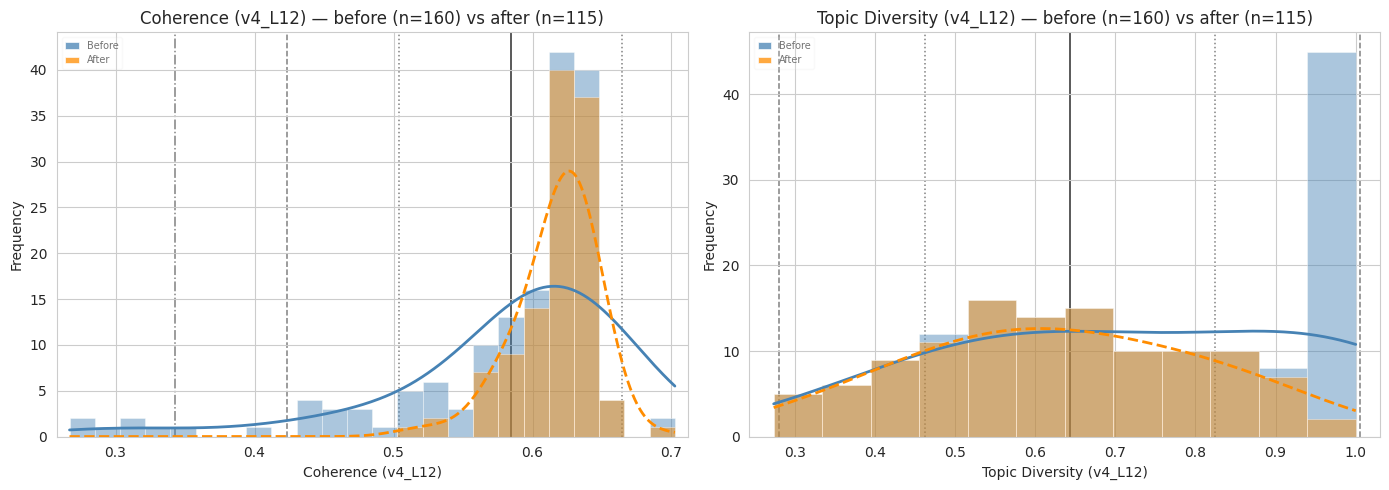

Coherence (v4_L6) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.6766, σ=0.0486
  ±1σ: [0.6280, 0.7252]
  ±2σ: [0.5794, 0.7737]
  ±3σ: [0.5308, 0.8223]
Topic Diversity (v4_L6) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.2993, σ=0.1486
  ±1σ: [0.1508, 0.4479]
  ±2σ: [0.0022, 0.5965]
  ±3σ: [-0.1464, 0.7450]


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/figures/distribution_raw_vs_filtered.png


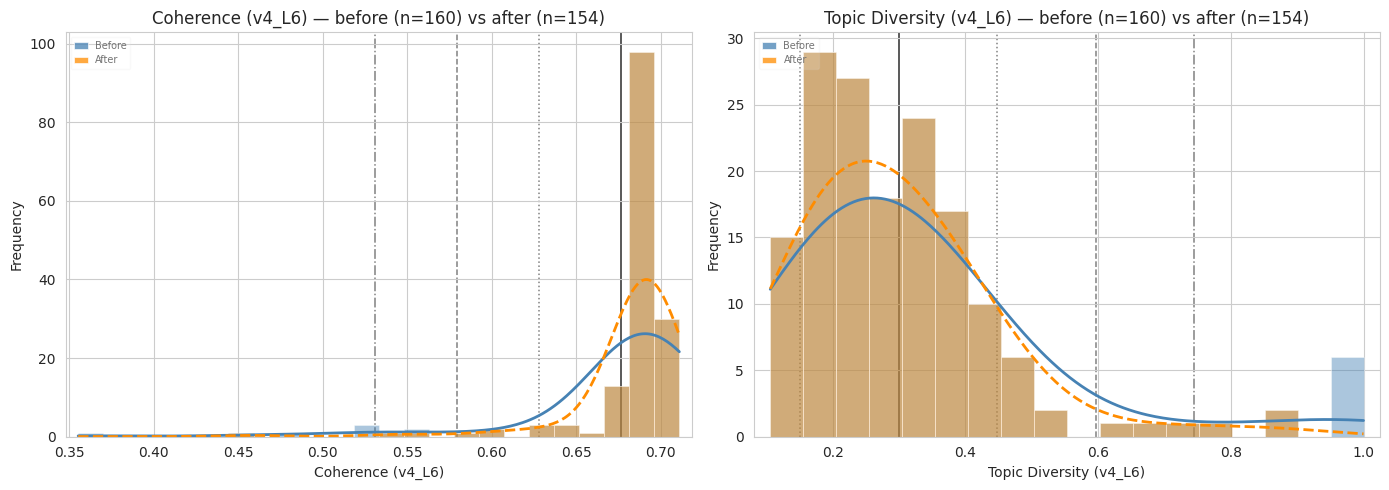

Coherence (v4_MPNet) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.5874, σ=0.1085
  ±1σ: [0.4789, 0.6959]
  ±2σ: [0.3704, 0.8044]
  ±3σ: [0.2619, 0.9129]
Topic Diversity (v4_MPNet) (μ, σ from before cleaning, excl. sentinels 0/1):
  μ=0.5771, σ=0.2056
  ±1σ: [0.3716, 0.7827]
  ±2σ: [0.1660, 0.9883]
  ±3σ: [-0.0395, 1.1938]


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/figures/distribution_raw_vs_filtered.png


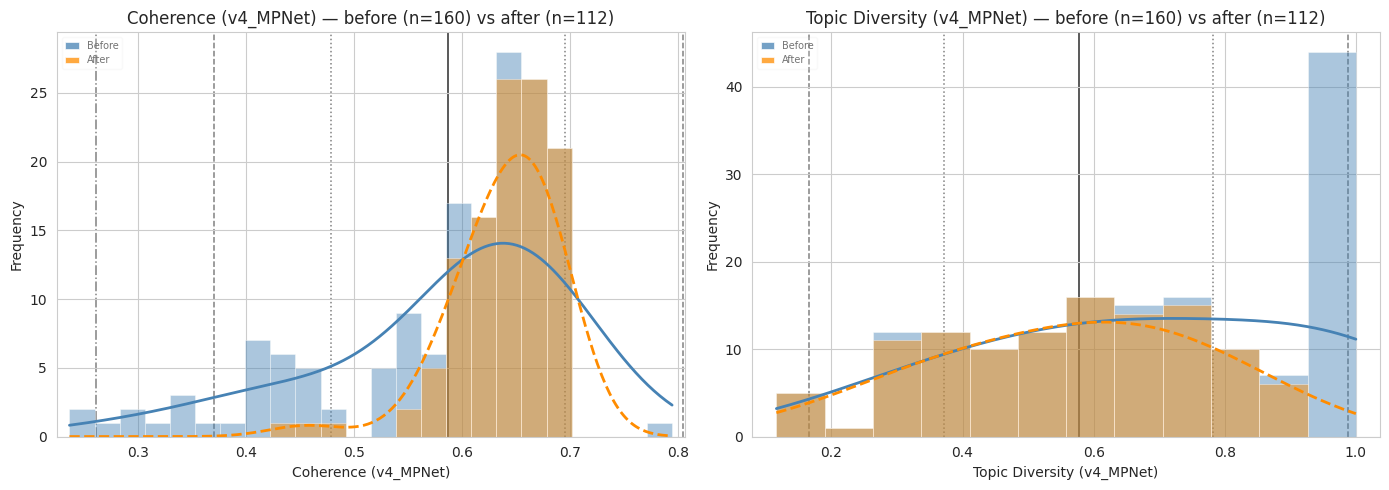

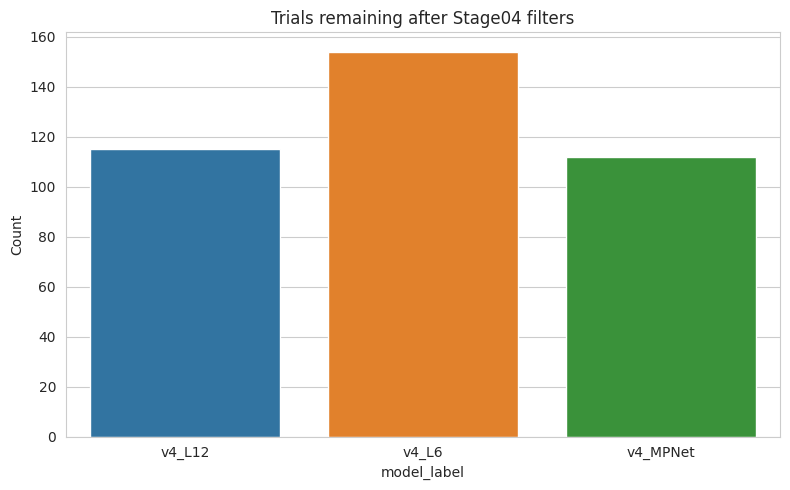

In [4]:
from scipy.stats import gaussian_kde

df_plot = df_trials.rename(columns=LEGACY_RENAME)
df_raw_plot = df_raw.rename(columns=LEGACY_RENAME)

STAGE_STYLE = {
    "before": {"color": "steelblue", "kde_ls": "-"},
    "after": {"color": "darkorange", "kde_ls": "--"},
}


def _sigma_reference(before: pd.Series) -> tuple[float, float]:
    """μ and σ from pre-cleaning trials, excluding obvious sentinel failures."""
    ref = before.dropna()
    ref = ref[(ref > 0) & (ref < 1.0)]
    return float(ref.mean()), float(ref.std())


def _shared_bin_edges(before: pd.Series, after: pd.Series, *, max_bins: int = 24) -> np.ndarray:
    """Freedman–Diaconis bins on the combined range, capped for readability."""
    combined = np.concatenate([before.dropna().values, after.dropna().values])
    edges = np.histogram_bin_edges(combined, bins="fd")
    if len(edges) < 10:
        edges = np.histogram_bin_edges(combined, bins=12)
    if len(edges) > max_bins + 1:
        lo, hi = combined.min(), combined.max()
        pad = max((hi - lo) * 0.02, 1e-4)
        edges = np.linspace(lo - pad, hi + pad, max_bins + 1)
    return edges


def _plot_kde_counts(
    ax, values: pd.Series, bin_edges: np.ndarray, *, color: str, linestyle: str
) -> None:
    x = values.dropna().values
    if len(x) < 2:
        return
    bin_width = np.mean(np.diff(bin_edges))
    kde = gaussian_kde(x)
    kde.set_bandwidth(kde.factor * 1.8)  # smoother shape curve for normality read-off
    x_grid = np.linspace(bin_edges[0], bin_edges[-1], 300)
    y = kde(x_grid) * len(x) * bin_width
    ax.plot(x_grid, y, color=color, linewidth=2, linestyle=linestyle, label="_nolegend_")


def plot_before_after_distribution(
    ax,
    before: pd.Series,
    after: pd.Series,
    metric_label: str,
) -> None:
    before = before.dropna()
    after = after.dropna()
    bin_edges = _shared_bin_edges(before, after)
    bin_width = np.mean(np.diff(bin_edges))

    ax.hist(
        before,
        bins=bin_edges,
        alpha=0.45,
        color=STAGE_STYLE["before"]["color"],
        edgecolor="white",
        linewidth=0.6,
        label="Before",
    )
    ax.hist(
        after,
        bins=bin_edges,
        alpha=0.45,
        color=STAGE_STYLE["after"]["color"],
        edgecolor="white",
        linewidth=0.6,
        label="After",
    )

    _plot_kde_counts(
        ax,
        before,
        bin_edges,
        color=STAGE_STYLE["before"]["color"],
        linestyle=STAGE_STYLE["before"]["kde_ls"],
    )
    _plot_kde_counts(
        ax,
        after,
        bin_edges,
        color=STAGE_STYLE["after"]["color"],
        linestyle=STAGE_STYLE["after"]["kde_ls"],
    )

    mu, sigma = _sigma_reference(before)
    sigma_linestyles = {1: ":", 2: "--", 3: "-."}
    for k in (1, 2, 3):
        for sign in (-1, 1):
            ax.axvline(
                mu + sign * k * sigma,
                color="0.45",
                linestyle=sigma_linestyles[k],
                linewidth=1.1,
                alpha=0.9,
                zorder=0,
            )
    ax.axvline(mu, color="black", linestyle="-", linewidth=1.3, alpha=0.7, zorder=0)

    ax.set_title(f"{metric_label} — before (n={len(before)}) vs after (n={len(after)})")
    ax.set_xlabel(metric_label)
    ax.set_ylabel("Frequency")
    ax.set_xlim(bin_edges[0] - bin_width * 0.5, bin_edges[-1] + bin_width * 0.5)

    legend = ax.legend(
        fontsize=7,
        loc="upper left",
        frameon=True,
        framealpha=0.15,
        edgecolor="0.85",
        facecolor="white",
        labelcolor="0.45",
        handlelength=1.4,
        borderpad=0.35,
    )
    for handle in legend.legend_handles:
        handle.set_alpha(0.75)

    print(f"{metric_label} (μ, σ from before cleaning, excl. sentinels 0/1):")
    print(f"  μ={mu:.4f}, σ={sigma:.4f}")
    for k in (1, 2, 3):
        print(f"  ±{k}σ: [{mu - k * sigma:.4f}, {mu + k * sigma:.4f}]")

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    run_fig = run_dirs[rid]["figures_dir"]
    df_plot = filtered_by_run[rid].rename(columns=LEGACY_RENAME)
    df_raw_plot = df_raw[df_raw["run_id"] == rid].rename(columns=LEGACY_RENAME)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_before_after_distribution(
        axes[0], df_raw_plot["Coherence"], df_plot["Coherence"], f"Coherence ({label})"
    )
    plot_before_after_distribution(
        axes[1], df_raw_plot["Topic_Diversity"], df_plot["Topic_Diversity"], f"Topic Diversity ({label})"
    )
    plt.tight_layout()
    out = run_fig / "distribution_raw_vs_filtered.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

if multi_run and cmp_dirs:
    last_steps = funnel_df.groupby("run_id").tail(1)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=last_steps, x="model_label", y="remaining", hue="model_label", legend=False, ax=ax)
    ax.set_title("Trials remaining after Stage04 filters")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(cmp_dirs["figures_dir"] / "selection_funnel_by_run.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4–5. Strategy A — Equal weights (50/50)

Normalize coherence and topic diversity, then compute a combined score with equal weights (0.5 each). Identify Pareto-efficient trials — points where no other trial is better on both metrics simultaneously — rank the Pareto set by combined score, and export the top **k** models.


[v4_L12] Equal weights — normalization: zscore | trials: 115
  Coherence weight: 0.50, topic-diversity weight: 0.50
  Pareto-efficient: 10 | Saved top 10


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
10,v4_l12_granular_phase1_1_call_19,sentence-transformers/all-MiniLM-L12-v2,0.648702,0.790698,1.059705
51,v4_l12_granular_phase1_1_call_79,sentence-transformers/all-MiniLM-L12-v2,0.640600,0.822006,1.003564
28,v4_l12_granular_phase1_1_call_49,sentence-transformers/all-MiniLM-L12-v2,0.653836,0.686327,0.845079
45,v4_l12_granular_phase1_1_call_73,sentence-transformers/all-MiniLM-L12-v2,0.656654,0.668693,0.844658
99,v4_l12_granular_phase1_1_call_142,sentence-transformers/all-MiniLM-L12-v2,0.624881,0.865546,0.843724
20,v4_l12_granular_phase1_1_call_36,sentence-transformers/all-MiniLM-L12-v2,0.610286,0.869081,0.586143
0,v4_l12_granular_phase1_1_call_0,sentence-transformers/all-MiniLM-L12-v2,0.595833,0.898058,0.406461
33,v4_l12_granular_phase1_1_call_55,sentence-transformers/all-MiniLM-L12-v2,0.694065,0.284615,0.394995
14,v4_l12_granular_phase1_1_call_26,sentence-transformers/all-MiniLM-L12-v2,0.571845,0.941772,0.095288
4,v4_l12_granular_phase1_1_call_11,sentence-transformers/all-MiniLM-L12-v2,0.510602,0.967172,-0.954327


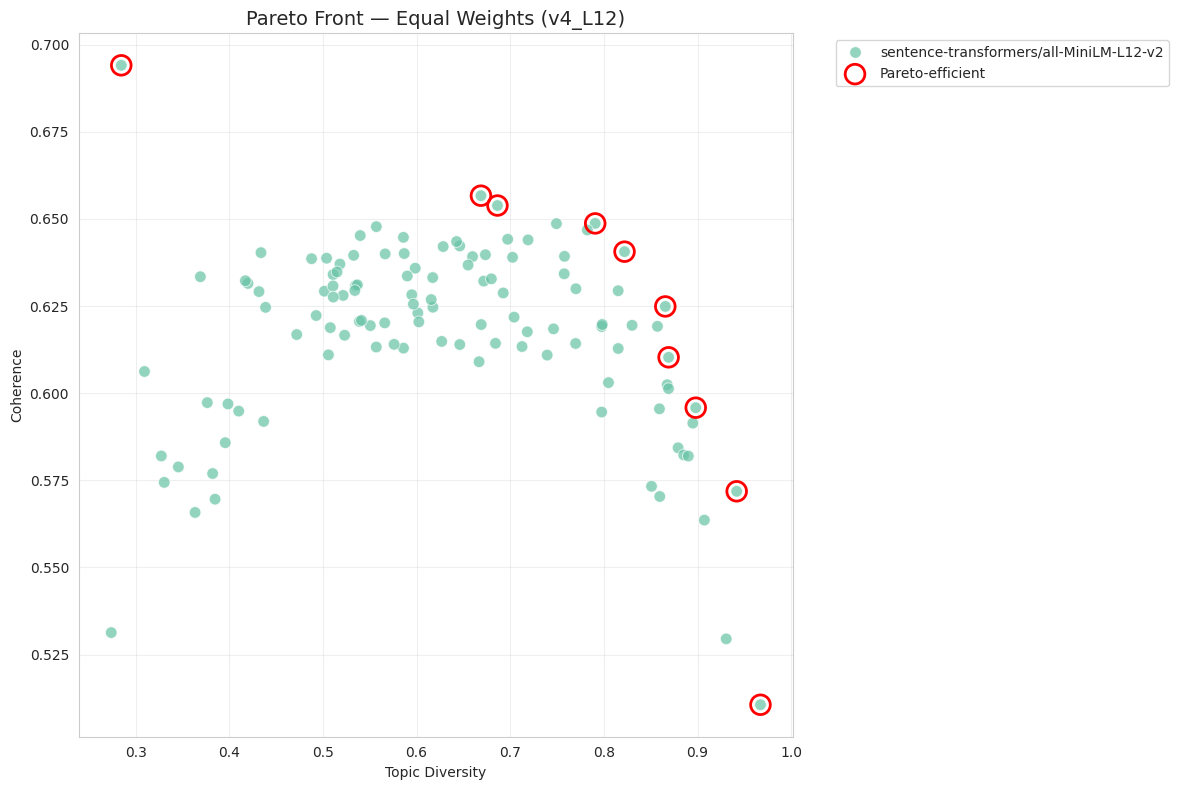


[v4_L6] Equal weights — normalization: zscore | trials: 154
  Coherence weight: 0.50, topic-diversity weight: 0.50
  Pareto-efficient: 19 | Saved top 19


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
105,v4_l6_granular_phase1_1_call_110,sentence-transformers/paraphrase-MiniLM-L6-v2,0.644227,0.779487,1.097094
58,v4_l6_granular_phase1_1_call_63,sentence-transformers/paraphrase-MiniLM-L6-v2,0.679913,0.548193,0.851272
11,v4_l6_granular_phase1_1_call_15,sentence-transformers/paraphrase-MiniLM-L6-v2,0.603146,0.869620,0.743920
44,v4_l6_granular_phase1_1_call_49,sentence-transformers/paraphrase-MiniLM-L6-v2,0.686402,0.480392,0.713594
146,v4_l6_granular_phase1_1_call_151,sentence-transformers/paraphrase-MiniLM-L6-v2,0.683651,0.484270,0.682149
81,v4_l6_granular_phase1_1_call_86,sentence-transformers/paraphrase-MiniLM-L6-v2,0.687301,0.463441,0.667231
33,v4_l6_granular_phase1_1_call_38,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694563,0.414931,0.612000
57,v4_l6_granular_phase1_1_call_62,sentence-transformers/paraphrase-MiniLM-L6-v2,0.692664,0.421739,0.605217
149,v4_l6_granular_phase1_1_call_155,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694643,0.397849,0.551611
24,v4_l6_granular_phase1_1_call_29,sentence-transformers/paraphrase-MiniLM-L6-v2,0.687472,0.422697,0.522885


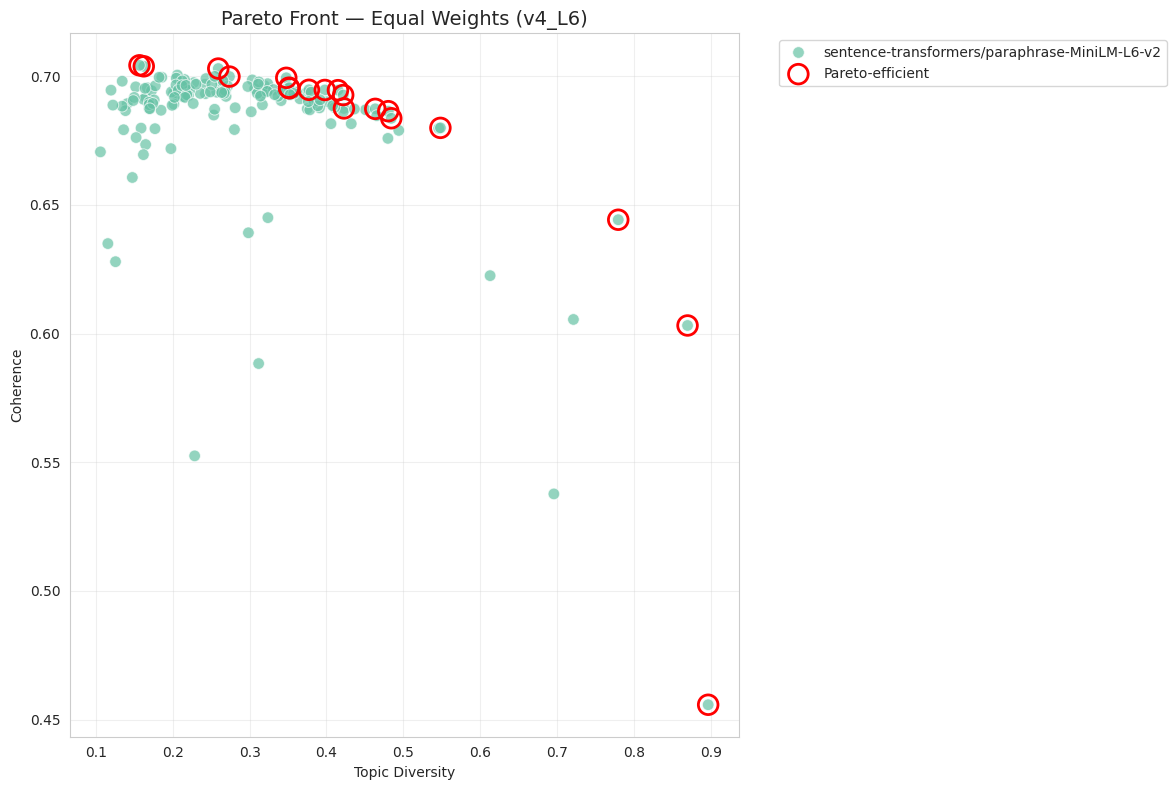


[v4_MPNet] Equal weights — normalization: zscore | trials: 112
  Coherence weight: 0.50, topic-diversity weight: 0.50
  Pareto-efficient: 17 | Saved top 17


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
102,v4_mpnet_granular_phase1_1_call_147,sentence-transformers/paraphrase-mpnet-base-v2,0.653354,0.703409,0.502159
95,v4_mpnet_granular_phase1_1_call_140,sentence-transformers/paraphrase-mpnet-base-v2,0.667169,0.637019,0.480631
109,v4_mpnet_granular_phase1_1_call_156,sentence-transformers/paraphrase-mpnet-base-v2,0.670268,0.609524,0.443563
45,v4_mpnet_granular_phase1_1_call_72,sentence-transformers/paraphrase-mpnet-base-v2,0.608144,0.863777,0.427099
48,v4_mpnet_granular_phase1_1_call_80,sentence-transformers/paraphrase-mpnet-base-v2,0.627564,0.755952,0.359755
51,v4_mpnet_granular_phase1_1_call_83,sentence-transformers/paraphrase-mpnet-base-v2,0.633143,0.732227,0.358953
23,v4_mpnet_granular_phase1_1_call_33,sentence-transformers/paraphrase-mpnet-base-v2,0.593249,0.898964,0.357242
89,v4_mpnet_granular_phase1_1_call_133,sentence-transformers/paraphrase-mpnet-base-v2,0.676514,0.544061,0.343176
74,v4_mpnet_granular_phase1_1_call_116,sentence-transformers/paraphrase-mpnet-base-v2,0.634530,0.710227,0.317573
7,v4_mpnet_granular_phase1_1_call_14,sentence-transformers/paraphrase-mpnet-base-v2,0.612819,0.796809,0.306004


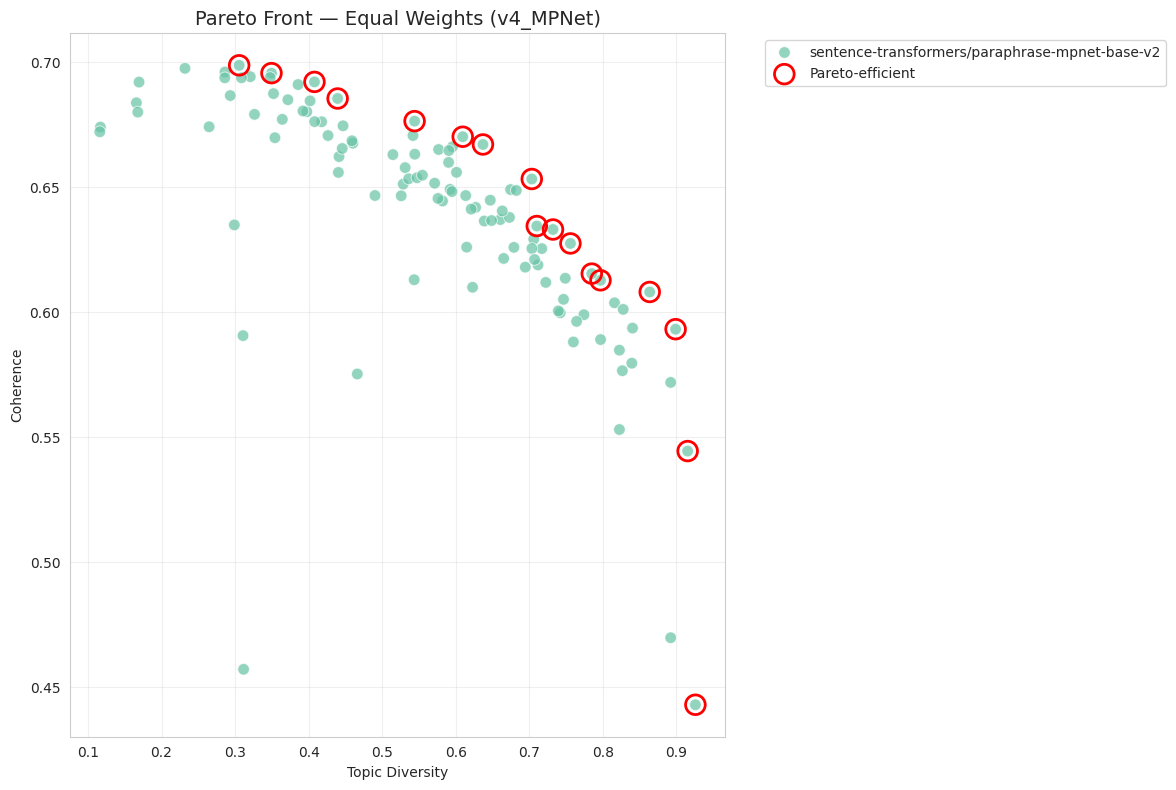

In [5]:
top_equal_by_run = {}
norm_method = nb_cfg["legacy_normalization"].get("method", "zscore")
w_eq = nb_cfg["weighting_strategies"]["equal_weights"]

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    run_fig = run_dirs[rid]["figures_dir"]
    run_top = run_dirs[rid]["top_models_dir"]
    df_trials_run = filtered_by_run[rid]

    df_legacy = df_trials_run.rename(columns=LEGACY_RENAME)
    df_norm = normalize_metrics(df_legacy.copy(), method=norm_method)
    print(f"\n[{label}] Equal weights — normalization: {norm_method} | trials: {len(df_norm)}")
    print(
        f"  Coherence weight: {w_eq['weight_coherence']:.2f}, "
        f"topic-diversity weight: {w_eq['weight_topic_diversity']:.2f}"
    )

    df_equal = calculate_combined_score(
        df_norm.copy(), float(w_eq["weight_coherence"]), float(w_eq["weight_topic_diversity"])
    )
    df_equal = analyze_pareto_efficiency(
        df_equal, metrics=PARETO_METRICS, per_model=nb_cfg["pareto"].get("analyze_per_model", True)
    )
    pareto_equal = df_equal[df_equal["Pareto_Efficient_All"]]
    top_equal = pareto_equal.nlargest(TOP_K, "Combined_Score")
    top_equal_by_run[rid] = top_equal
    top_equal.to_csv(run_top / STRATEGY_FILES["equal_weights"], index=False)
    print(f"  Pareto-efficient: {len(pareto_equal)} | Saved top {len(top_equal)}")

    display(
        top_equal[["trial_id", "Embeddings_Model", "Coherence", "Topic_Diversity", "Combined_Score"]].head(TOP_K)
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=df_equal, x="Topic_Diversity", y="Coherence", hue="Embeddings_Model",
        palette="Set2", s=70, alpha=0.7, ax=ax,
    )
    ax.scatter(
        pareto_equal["Topic_Diversity"], pareto_equal["Coherence"],
        facecolors="none", edgecolors="red", s=200, linewidths=2, label="Pareto-efficient", zorder=10,
    )
    ax.set_title(f"Pareto Front — Equal Weights ({label})", fontsize=14)
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(run_fig / "pareto_front_equal_weights.png", dpi=150, bbox_inches="tight")
    plt.show()

top_equal = top_equal_by_run[primary_run["run_id"]]


## 6. Strategy B — Coherence priority (70/30)

Reuses z-scored metrics from Strategy A, but ranks with **70% coherence / 30% topic diversity**. Pareto efficiency is computed on the same normalized axes (weights do not change the frontier); only the ranking within the Pareto set differs from Strategy A.


[v4_L12] Coherence priority — Pareto: 10 | Saved top 10


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
33,v4_l12_granular_phase1_1_call_55,sentence-transformers/all-MiniLM-L12-v2,0.694065,0.284615,1.366062
10,v4_l12_granular_phase1_1_call_19,sentence-transformers/all-MiniLM-L12-v2,0.648702,0.790698,1.098392
45,v4_l12_granular_phase1_1_call_73,sentence-transformers/all-MiniLM-L12-v2,0.656654,0.668693,1.086201
28,v4_l12_granular_phase1_1_call_49,sentence-transformers/all-MiniLM-L12-v2,0.653836,0.686327,1.045037
51,v4_l12_granular_phase1_1_call_79,sentence-transformers/all-MiniLM-L12-v2,0.640600,0.822006,0.945665
99,v4_l12_granular_phase1_1_call_142,sentence-transformers/all-MiniLM-L12-v2,0.624881,0.865546,0.618799
20,v4_l12_granular_phase1_1_call_36,sentence-transformers/all-MiniLM-L12-v2,0.610286,0.869081,0.249816
0,v4_l12_granular_phase1_1_call_0,sentence-transformers/all-MiniLM-L12-v2,0.595833,0.898058,-0.070350
14,v4_l12_granular_phase1_1_call_26,sentence-transformers/all-MiniLM-L12-v2,0.571845,0.941772,-0.609494
4,v4_l12_granular_phase1_1_call_11,sentence-transformers/all-MiniLM-L12-v2,0.510602,0.967172,-2.139095


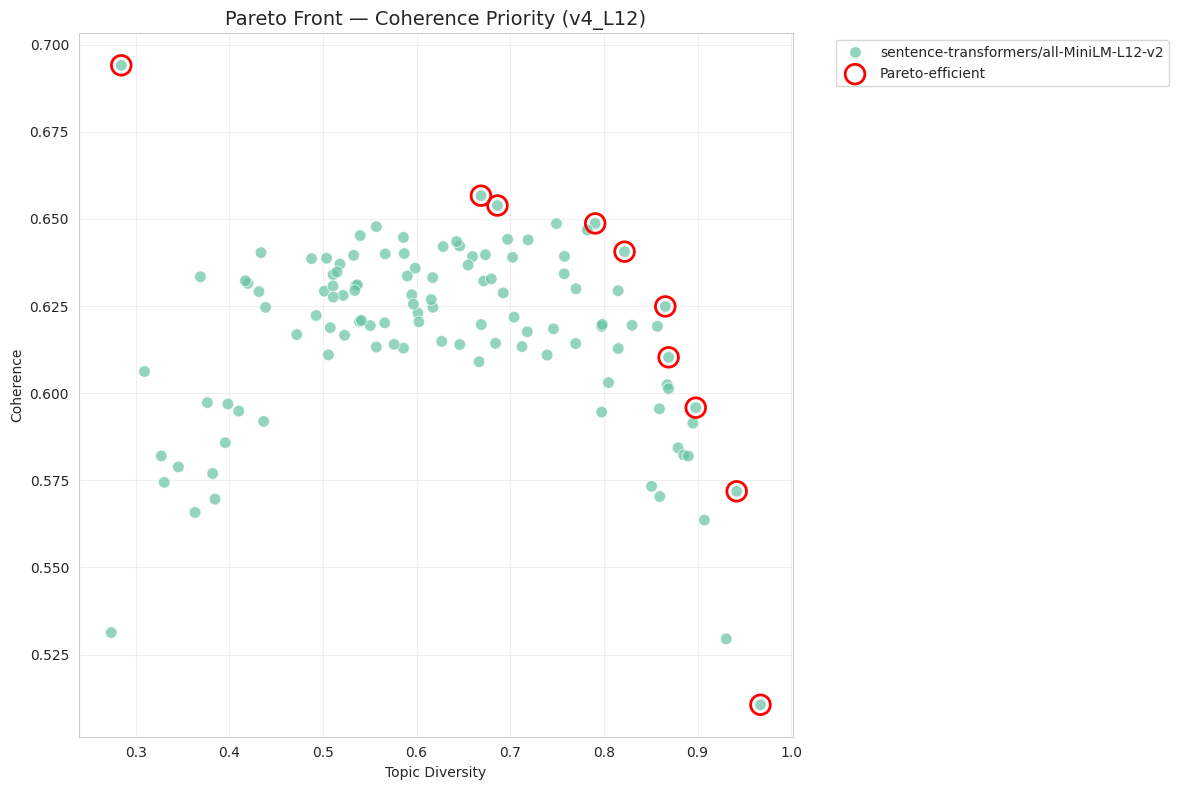


[v4_L6] Coherence priority — Pareto: 19 | Saved top 19


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
33,v4_l6_granular_phase1_1_call_38,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694563,0.414931,0.510250
57,v4_l6_granular_phase1_1_call_62,sentence-transformers/paraphrase-MiniLM-L6-v2,0.692664,0.421739,0.481080
16,v4_l6_granular_phase1_1_call_20,sentence-transformers/paraphrase-MiniLM-L6-v2,0.699364,0.347727,0.475648
149,v4_l6_granular_phase1_1_call_155,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694643,0.397849,0.475062
44,v4_l6_granular_phase1_1_call_49,sentence-transformers/paraphrase-MiniLM-L6-v2,0.686402,0.480392,0.463327
58,v4_l6_granular_phase1_1_call_63,sentence-transformers/paraphrase-MiniLM-L6-v2,0.679913,0.548193,0.460165
81,v4_l6_granular_phase1_1_call_86,sentence-transformers/paraphrase-MiniLM-L6-v2,0.687301,0.463441,0.447401
51,v4_l6_granular_phase1_1_call_56,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694701,0.377174,0.431616
146,v4_l6_granular_phase1_1_call_151,sentence-transformers/paraphrase-MiniLM-L6-v2,0.683651,0.484270,0.408100
107,v4_l6_granular_phase1_1_call_112,sentence-transformers/paraphrase-MiniLM-L6-v2,0.695524,0.351282,0.394539


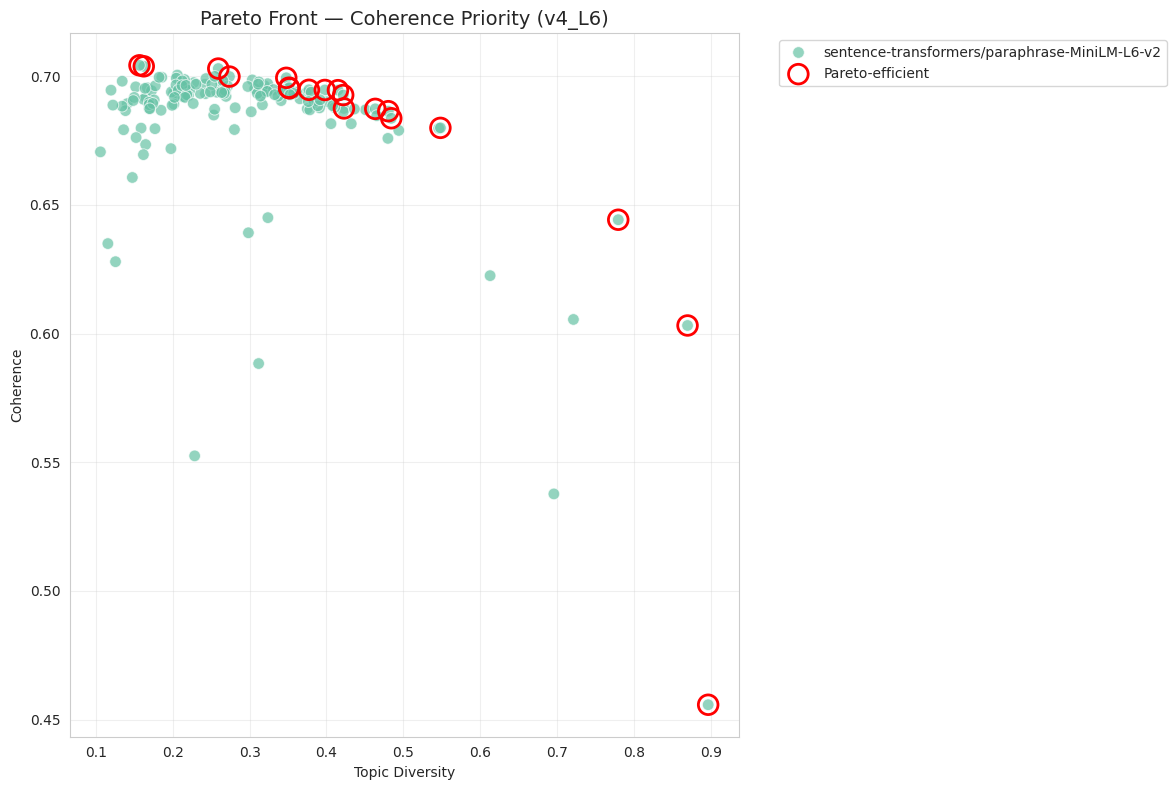


[v4_MPNet] Coherence priority — Pareto: 17 | Saved top 17


,trial_id,Embeddings_Model,Coherence,Topic_Diversity,Combined_Score
104,v4_mpnet_granular_phase1_1_call_149,sentence-transformers/paraphrase-mpnet-base-v2,0.692207,0.407937,0.548941
109,v4_mpnet_granular_phase1_1_call_156,sentence-transformers/paraphrase-mpnet-base-v2,0.670268,0.609524,0.528645
95,v4_mpnet_granular_phase1_1_call_140,sentence-transformers/paraphrase-mpnet-base-v2,0.667169,0.637019,0.524285
89,v4_mpnet_granular_phase1_1_call_133,sentence-transformers/paraphrase-mpnet-base-v2,0.676514,0.544061,0.522040
13,v4_mpnet_granular_phase1_1_call_21,sentence-transformers/paraphrase-mpnet-base-v2,0.695719,0.349495,0.512031
12,v4_mpnet_granular_phase1_1_call_20,sentence-transformers/paraphrase-mpnet-base-v2,0.685565,0.439423,0.497471
87,v4_mpnet_granular_phase1_1_call_131,sentence-transformers/paraphrase-mpnet-base-v2,0.698850,0.305556,0.491644
102,v4_mpnet_granular_phase1_1_call_147,sentence-transformers/paraphrase-mpnet-base-v2,0.653354,0.703409,0.418591
51,v4_mpnet_granular_phase1_1_call_83,sentence-transformers/paraphrase-mpnet-base-v2,0.633143,0.732227,0.159140
74,v4_mpnet_granular_phase1_1_call_116,sentence-transformers/paraphrase-mpnet-base-v2,0.634530,0.710227,0.146221


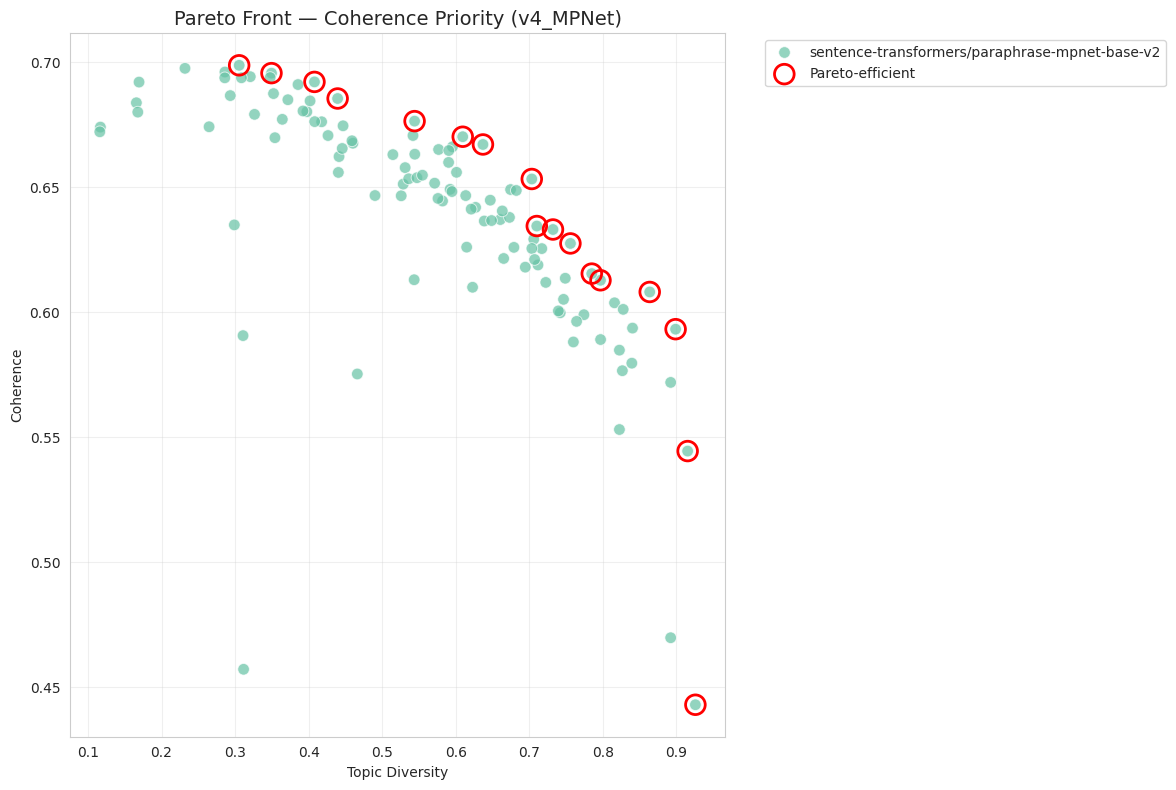

In [6]:
top_priority_by_run = {}
w_cp = nb_cfg["weighting_strategies"]["coherence_priority"]

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    run_fig = run_dirs[rid]["figures_dir"]
    run_top = run_dirs[rid]["top_models_dir"]
    df_trials_run = filtered_by_run[rid]

    df_legacy = df_trials_run.rename(columns=LEGACY_RENAME)
    df_norm = normalize_metrics(df_legacy.copy(), method=norm_method)
    df_priority = calculate_combined_score(
        df_norm.copy(), float(w_cp["weight_coherence"]), float(w_cp["weight_topic_diversity"])
    )
    df_priority = analyze_pareto_efficiency(df_priority, metrics=PARETO_METRICS, per_model=False)
    pareto_priority = df_priority[df_priority["Pareto_Efficient_All"]]
    top_priority = pareto_priority.nlargest(TOP_K, "Combined_Score")
    top_priority_by_run[rid] = top_priority
    top_priority.to_csv(run_top / STRATEGY_FILES["coherence_priority"], index=False)
    print(f"\n[{label}] Coherence priority — Pareto: {len(pareto_priority)} | Saved top {len(top_priority)}")

    display(
        top_priority[["trial_id", "Embeddings_Model", "Coherence", "Topic_Diversity", "Combined_Score"]].head(TOP_K)
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=df_priority, x="Topic_Diversity", y="Coherence", hue="Embeddings_Model",
        palette="Set2", s=70, alpha=0.7, ax=ax,
    )
    ax.scatter(
        pareto_priority["Topic_Diversity"], pareto_priority["Coherence"],
        facecolors="none", edgecolors="red", s=200, linewidths=2, label="Pareto-efficient", zorder=10,
    )
    ax.set_title(f"Pareto Front — Coherence Priority ({label})", fontsize=14)
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(run_fig / "pareto_front_coherence_priority.png", dpi=150, bbox_inches="tight")
    plt.show()

top_priority = top_priority_by_run[primary_run["run_id"]]


## 7. Strategy C — eval_select (current pipeline)

Mirrors `src.stage04_eval_select.cli select` with the config from `eval_select_config` (granular: 45% coherence, 20% diversity, +15% topic-count floor, −10% outlier rate, −10% stability penalty): **min-max** normalize coherence and topic diversity to [0, 1], keep Pareto-efficient trials, then rank survivors with the production weighted objective. Validates notebook output against CLI `top_k.csv` when present.

Weighted-score weights (configs/stage04/eval_select_granular.yaml): coherence=0.45, diversity=0.2, topic_count_floor=0.15, outlier=0.1, stability=0.1

[v4_L12] eval_select — Pareto candidates: 10 | Saved top 10


,trial_id,Embeddings_Model,coherence_c_v,topic_diversity,weighted_score
99,v4_l12_granular_phase1_1_call_142,sentence-transformers/all-MiniLM-L12-v2,0.624881,0.865546,0.534205
51,v4_l12_granular_phase1_1_call_79,sentence-transformers/all-MiniLM-L12-v2,0.640600,0.822006,0.531468
20,v4_l12_granular_phase1_1_call_36,sentence-transformers/all-MiniLM-L12-v2,0.610286,0.869081,0.529379
14,v4_l12_granular_phase1_1_call_26,sentence-transformers/all-MiniLM-L12-v2,0.571845,0.941772,0.527197
10,v4_l12_granular_phase1_1_call_19,sentence-transformers/all-MiniLM-L12-v2,0.648702,0.790698,0.527095
0,v4_l12_granular_phase1_1_call_0,sentence-transformers/all-MiniLM-L12-v2,0.595833,0.898058,0.527084
28,v4_l12_granular_phase1_1_call_49,sentence-transformers/all-MiniLM-L12-v2,0.653836,0.686327,0.512233
45,v4_l12_granular_phase1_1_call_73,sentence-transformers/all-MiniLM-L12-v2,0.656654,0.668693,0.508753
4,v4_l12_granular_phase1_1_call_11,sentence-transformers/all-MiniLM-L12-v2,0.510602,0.967172,0.501317
33,v4_l12_granular_phase1_1_call_55,sentence-transformers/all-MiniLM-L12-v2,0.694065,0.284615,0.447078


  CLI validation — winner match: True, overlap: 10/10, score match: True


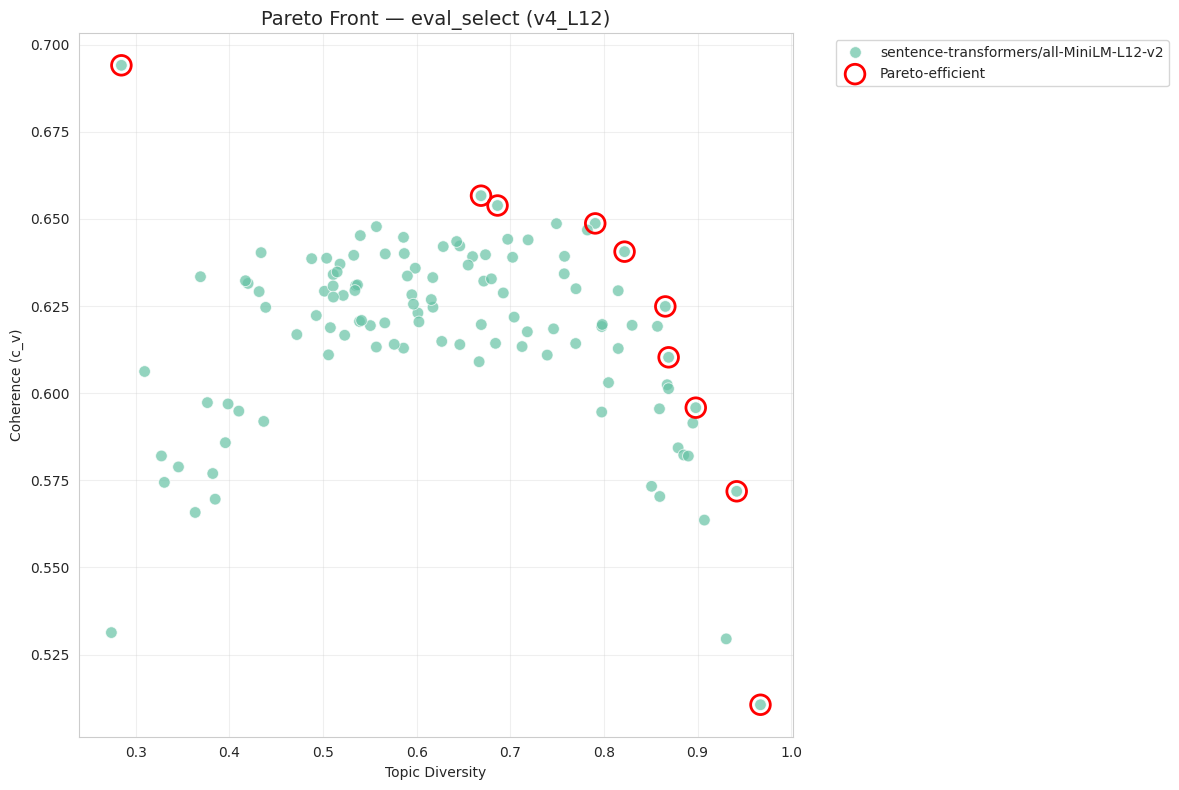


[v4_L6] eval_select — Pareto candidates: 19 | Saved top 19


,trial_id,Embeddings_Model,coherence_c_v,topic_diversity,weighted_score
105,v4_l6_granular_phase1_1_call_110,sentence-transformers/paraphrase-MiniLM-L6-v2,0.644227,0.779487,0.514104
11,v4_l6_granular_phase1_1_call_15,sentence-transformers/paraphrase-MiniLM-L6-v2,0.603146,0.869620,0.512400
58,v4_l6_granular_phase1_1_call_63,sentence-transformers/paraphrase-MiniLM-L6-v2,0.679913,0.548193,0.484521
44,v4_l6_granular_phase1_1_call_49,sentence-transformers/paraphrase-MiniLM-L6-v2,0.686402,0.480392,0.474188
146,v4_l6_granular_phase1_1_call_151,sentence-transformers/paraphrase-MiniLM-L6-v2,0.683651,0.484270,0.473448
81,v4_l6_granular_phase1_1_call_86,sentence-transformers/paraphrase-MiniLM-L6-v2,0.687301,0.463441,0.470675
57,v4_l6_granular_phase1_1_call_62,sentence-transformers/paraphrase-MiniLM-L6-v2,0.692664,0.421739,0.465226
33,v4_l6_granular_phase1_1_call_38,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694563,0.414931,0.464455
149,v4_l6_granular_phase1_1_call_155,sentence-transformers/paraphrase-MiniLM-L6-v2,0.694643,0.397849,0.460933
24,v4_l6_granular_phase1_1_call_29,sentence-transformers/paraphrase-MiniLM-L6-v2,0.687472,0.422697,0.460593


  CLI validation — winner match: True, overlap: 19/19, score match: True


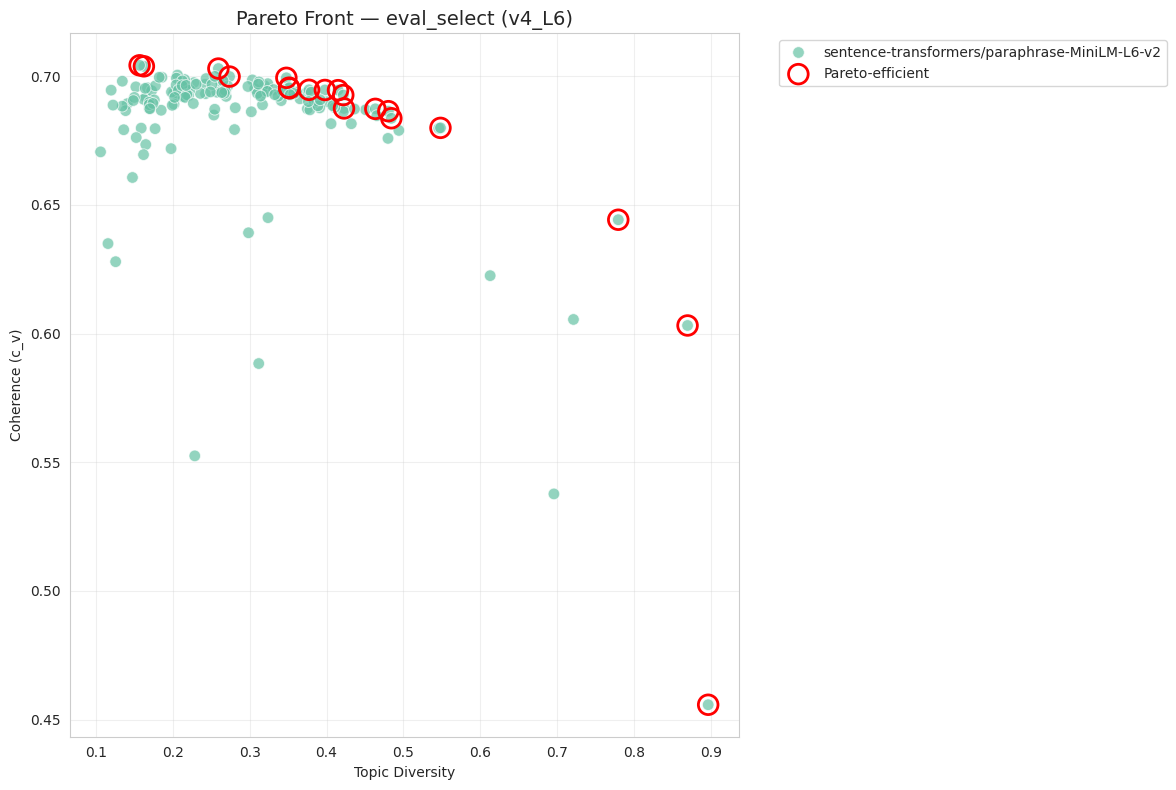


[v4_MPNet] eval_select — Pareto candidates: 17 | Saved top 17


,trial_id,Embeddings_Model,coherence_c_v,topic_diversity,weighted_score
23,v4_mpnet_granular_phase1_1_call_33,sentence-transformers/paraphrase-mpnet-base-v2,0.593249,0.898964,0.524179
45,v4_mpnet_granular_phase1_1_call_72,sentence-transformers/paraphrase-mpnet-base-v2,0.608144,0.863777,0.522637
48,v4_mpnet_granular_phase1_1_call_80,sentence-transformers/paraphrase-mpnet-base-v2,0.627564,0.755952,0.507737
25,v4_mpnet_granular_phase1_1_call_38,sentence-transformers/paraphrase-mpnet-base-v2,0.544471,0.915332,0.505829
51,v4_mpnet_granular_phase1_1_call_83,sentence-transformers/paraphrase-mpnet-base-v2,0.633143,0.732227,0.505361
7,v4_mpnet_granular_phase1_1_call_14,sentence-transformers/paraphrase-mpnet-base-v2,0.612819,0.796809,0.505015
74,v4_mpnet_granular_phase1_1_call_116,sentence-transformers/paraphrase-mpnet-base-v2,0.634530,0.710227,0.503020
102,v4_mpnet_granular_phase1_1_call_147,sentence-transformers/paraphrase-mpnet-base-v2,0.653354,0.703409,0.502902
8,v4_mpnet_granular_phase1_1_call_15,sentence-transformers/paraphrase-mpnet-base-v2,0.615488,0.785000,0.502707
95,v4_mpnet_granular_phase1_1_call_140,sentence-transformers/paraphrase-mpnet-base-v2,0.667169,0.637019,0.502414


  CLI validation — winner match: True, overlap: 17/17, score match: True


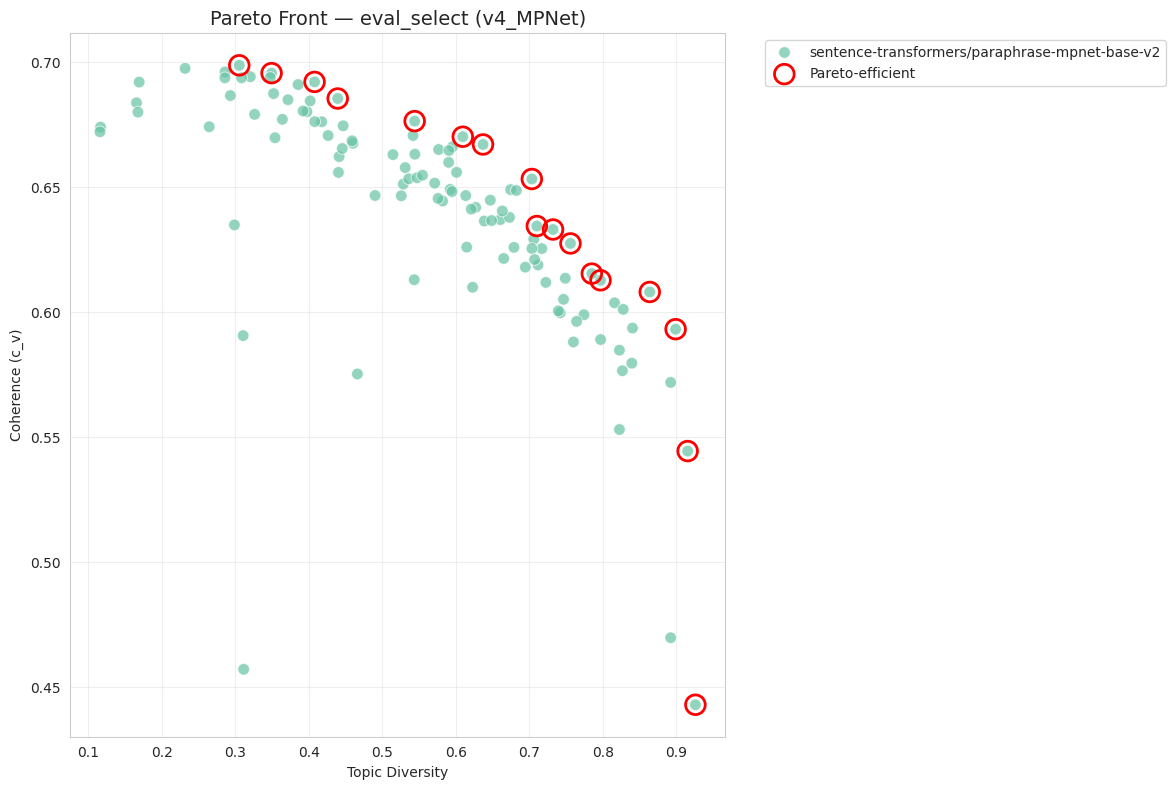

In [7]:
top_eval_by_run = {}
weights = eval_cfg["weights"]
w_topic_floor = float(weights.get("topic_count_floor", 0.0))
print(
    f"Weighted-score weights ({nb_cfg['eval_select_config']}): "
    f"coherence={weights['coherence']}, diversity={weights['diversity']}, "
    f"topic_count_floor={w_topic_floor}, "
    f"outlier={weights['outlier']}, stability={weights['stability']}"
)

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    run_fig = run_dirs[rid]["figures_dir"]
    run_top = run_dirs[rid]["top_models_dir"]
    cli_top_k_path = resolve_path(Path(run["inputs"]["eval_select_top_k"]), project_root)
    df_trials_run = filtered_by_run[rid]

    df_eval = normalize_for_pareto(df_trials_run.copy())
    df_eval_p = df_eval.rename(
        columns={
            "coherence_c_v_norm": "Coherence_norm",
            "topic_diversity_norm": "Topic_Diversity_norm",
            "embedding_model": "Embeddings_Model",
        }
    )
    df_eval_p = analyze_pareto_efficiency(df_eval_p, metrics=PARETO_METRICS, per_model=False)
    candidates = df_eval_p[df_eval_p["Pareto_Efficient_All"]].copy()
    candidates = apply_weighted_score(
        candidates,
        float(weights["coherence"]),
        float(weights["diversity"]),
        float(weights["outlier"]),
        float(weights["stability"]),
        w_topic_count_floor=w_topic_floor,
    )
    candidates = candidates.sort_values("weighted_score", ascending=False)
    top_eval = candidates.head(TOP_K)
    top_eval_by_run[rid] = top_eval
    top_eval.to_csv(run_top / STRATEGY_FILES["eval_select"], index=False)
    print(f"\n[{label}] eval_select — Pareto candidates: {len(candidates)} | Saved top {len(top_eval)}")

    display(
        top_eval[["trial_id", "Embeddings_Model", "coherence_c_v", "topic_diversity", "weighted_score"]].head(TOP_K)
    )

    if cli_top_k_path.exists():
        cli_top = pd.read_csv(cli_top_k_path)
        winner_match = top_eval.iloc[0]["trial_id"] == cli_top.iloc[0]["trial_id"]
        overlap = len(set(top_eval["trial_id"]) & set(cli_top["trial_id"]))
        score_ok = abs(float(top_eval.iloc[0]["weighted_score"]) - float(cli_top.iloc[0]["weighted_score"])) < 1e-6
        print(f"  CLI validation — winner match: {winner_match}, overlap: {overlap}/{len(cli_top)}, score match: {score_ok}")
    else:
        print(f"  CLI top_k not found: {cli_top_k_path}")

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=df_eval, x="topic_diversity", y="coherence_c_v", hue="embedding_model",
        palette="Set2", s=70, alpha=0.7, ax=ax,
    )
    pareto_v3 = df_eval_p[df_eval_p["Pareto_Efficient_All"]]
    ax.scatter(
        pareto_v3["topic_diversity"], pareto_v3["coherence_c_v"],
        facecolors="none", edgecolors="red", s=200, linewidths=2, label="Pareto-efficient", zorder=10,
    )
    ax.set_title(f"Pareto Front — eval_select ({label})", fontsize=14)
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence (c_v)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(run_fig / "pareto_front_eval_select.png", dpi=150, bbox_inches="tight")
    plt.show()

top_eval = top_eval_by_run[primary_run["run_id"]]


## 7b. Cross-model comparison

Overlay filtered trials and top-1 winners per run (when `runs` has more than one entry). Outputs go to `comparison.base_dir` in `configs/stage04/selection_notebooks.yaml`.

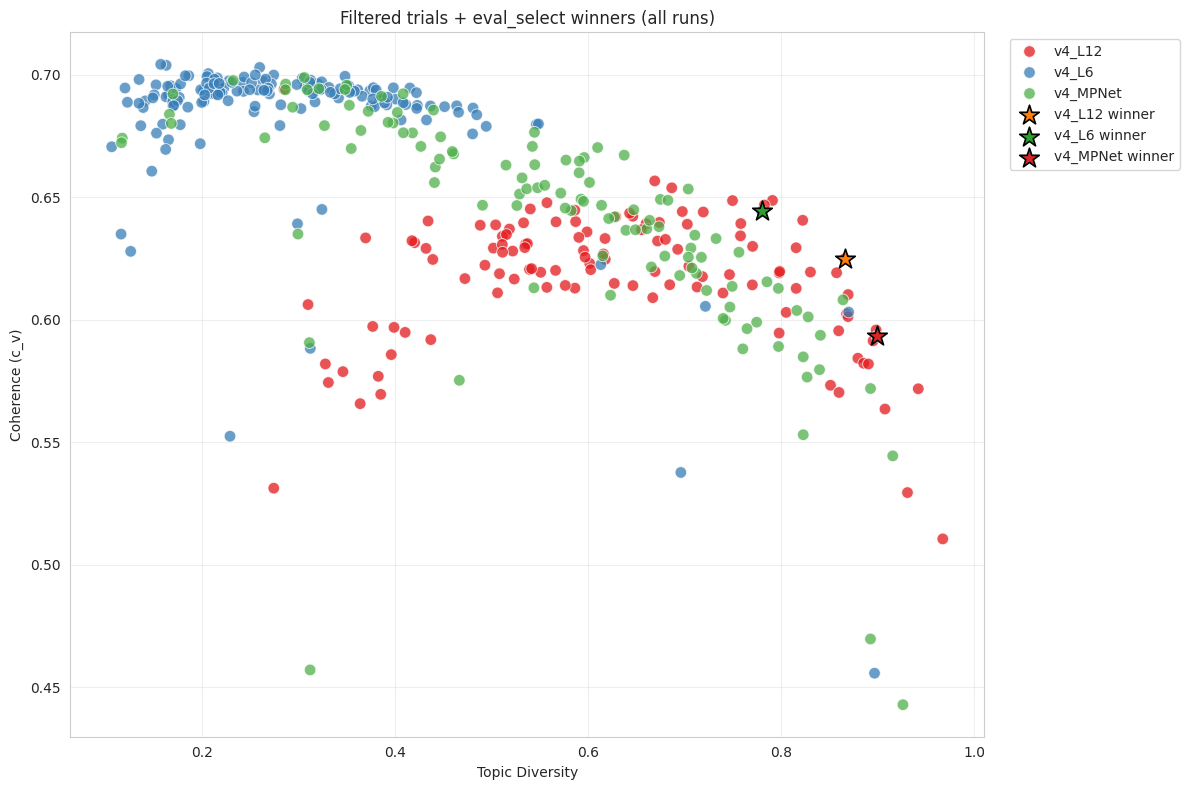

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/winners_by_run_and_strategy.csv


,model_label,strategy,trial_id,coherence_c_v,topic_diversity,n_topics,weighted_score,Combined_Score
0,v4_L12,equal_weights,v4_l12_granular_phase1_1_call_19,NaN,NaN,301.0,NaN,1.059705
1,v4_L12,coherence_priority,v4_l12_granular_phase1_1_call_55,NaN,NaN,117.0,NaN,1.366062
2,v4_L12,eval_select,v4_l12_granular_phase1_1_call_142,0.624881,0.865546,357.0,0.534205,NaN
3,v4_L6,equal_weights,v4_l6_granular_phase1_1_call_110,NaN,NaN,78.0,NaN,1.097094
4,v4_L6,coherence_priority,v4_l6_granular_phase1_1_call_38,NaN,NaN,96.0,NaN,0.510250
5,v4_L6,eval_select,v4_l6_granular_phase1_1_call_110,0.644227,0.779487,78.0,0.514104,NaN
6,v4_MPNet,equal_weights,v4_mpnet_granular_phase1_1_call_147,NaN,NaN,88.0,NaN,0.502159
7,v4_MPNet,coherence_priority,v4_mpnet_granular_phase1_1_call_149,NaN,NaN,105.0,NaN,0.548941
8,v4_MPNet,eval_select,v4_mpnet_granular_phase1_1_call_33,0.593249,0.898964,386.0,0.524179,NaN


In [8]:
if multi_run and cmp_dirs:
    # Overlay all filtered trials
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=df_trials,
        x="topic_diversity",
        y="coherence_c_v",
        hue="model_label",
        palette="Set1",
        s=70,
        alpha=0.75,
        ax=ax,
    )
    winners = []
    for run in runs:
        rid = run["run_id"]
        w = top_eval_by_run[rid].iloc[0]
        winners.append(w)
        ax.scatter(
            w["topic_diversity"], w["coherence_c_v"],
            s=220, marker="*", edgecolors="black", linewidths=1.2, zorder=12,
            label=f"{run.get('label', rid)} winner",
        )
    ax.set_title("Filtered trials + eval_select winners (all runs)")
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence (c_v)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(cmp_dirs["figures_dir"] / "pareto_overlay_eval_select.png", dpi=150, bbox_inches="tight")
    plt.show()

    winner_rows = []
    for run in runs:
        rid = run["run_id"]
        for strategy, top_map in [
            ("equal_weights", top_equal_by_run),
            ("coherence_priority", top_priority_by_run),
            ("eval_select", top_eval_by_run),
        ]:
            top_df = top_map[rid]
            row = top_df.iloc[0].to_dict()
            row["strategy"] = strategy
            row["run_id"] = rid
            row["model_label"] = run.get("label", rid)
            winner_rows.append(row)
    winners_df = pd.DataFrame(winner_rows)
    winners_path = cmp_dirs["tables_dir"] / "winners_by_run_and_strategy.csv"
    winners_df.to_csv(winners_path, index=False)
    print(f"Saved {winners_path}")
    display(
        winners_df[
            [c for c in ["model_label", "strategy", "trial_id", "coherence_c_v", "topic_diversity", "n_topics", "weighted_score", "Combined_Score"] if c in winners_df.columns]
        ]
    )
else:
    print("Single-run mode: skipping cross-model comparison section.")


## 8. Cross-strategy comparison

Compare top-**k** trial sets from all three strategies: pairwise overlap counts, union size, **per-trial parameter dumps** (metrics, `n_topics`, hyperparameters), and a scatter plot tagging each trial by which strategy(ies) selected it (A = equal weights, B = coherence priority, C = eval_select).


Cross-strategy comparison — v4_L12 (v4_l12_granular_phase1_dryrun)
Top-k sizes: {'equal_weights': 10, 'coherence_priority': 10, 'eval_select': 10}
Union of all selected trials: 10


,strategy,compare_to,overlap_count
0,equal_weights,coherence_priority,10
1,equal_weights,eval_select,10
2,coherence_priority,equal_weights,10
3,coherence_priority,eval_select,10
4,eval_select,equal_weights,10
5,eval_select,coherence_priority,10


,strategy,top_k_count,trial_ids
0,equal_weights,10,v4_l12_granular_phase1_1_call_0;v4_l12_granula...
1,coherence_priority,10,v4_l12_granular_phase1_1_call_0;v4_l12_granula...
2,eval_select,10,v4_l12_granular_phase1_1_call_0;v4_l12_granula...



equal_weights (A) — 10 selected trial(s)

coherence_priority (B) — 10 selected trial(s)

eval_select (C) — 10 selected trial(s)
Saved trial details: /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l12_granular_phase1_dryrun/notebook_analysis/tables/strategy_selected_trial_details.csv


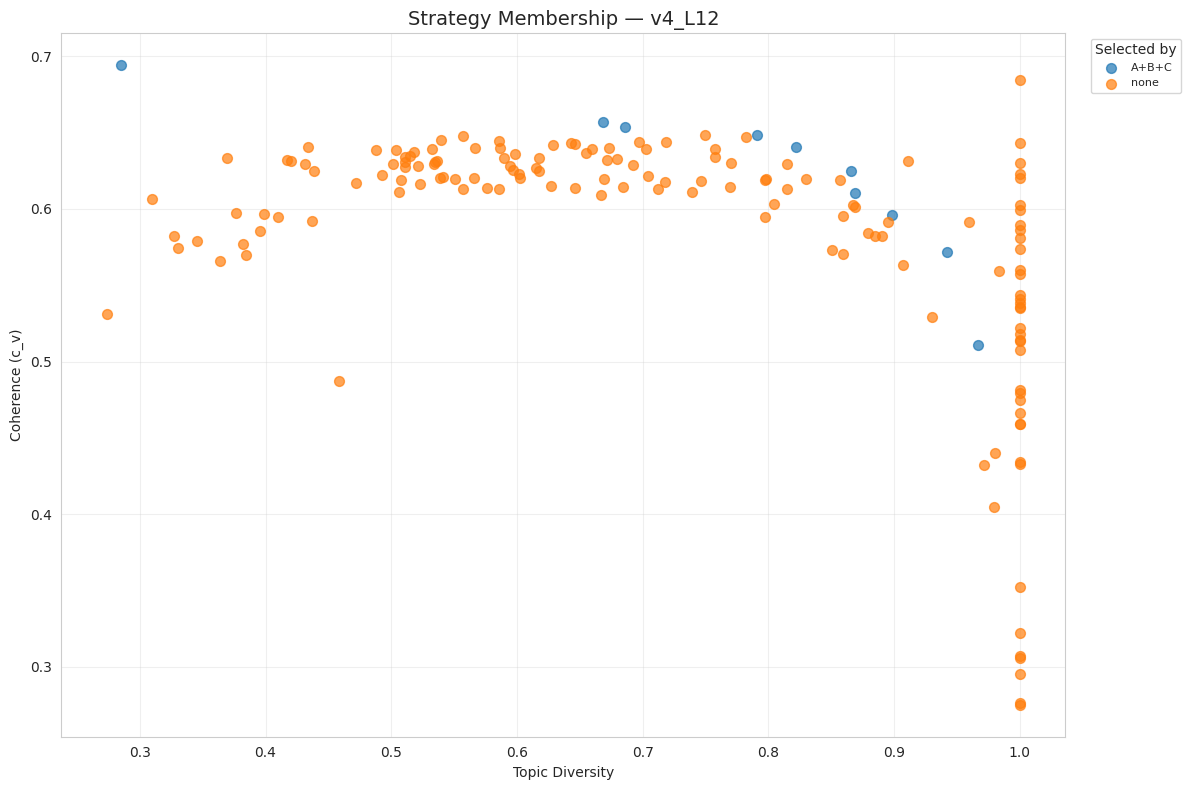


Cross-strategy comparison — v4_L6 (v4_l6_granular_phase1_dryrun)
Top-k sizes: {'equal_weights': 19, 'coherence_priority': 19, 'eval_select': 19}
Union of all selected trials: 19


,strategy,compare_to,overlap_count
0,equal_weights,coherence_priority,19
1,equal_weights,eval_select,19
2,coherence_priority,equal_weights,19
3,coherence_priority,eval_select,19
4,eval_select,equal_weights,19
5,eval_select,coherence_priority,19


,strategy,top_k_count,trial_ids
0,equal_weights,19,v4_l6_granular_phase1_1_call_110;v4_l6_granula...
1,coherence_priority,19,v4_l6_granular_phase1_1_call_110;v4_l6_granula...
2,eval_select,19,v4_l6_granular_phase1_1_call_110;v4_l6_granula...



equal_weights (A) — 19 selected trial(s)

coherence_priority (B) — 19 selected trial(s)

eval_select (C) — 19 selected trial(s)
Saved trial details: /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_l6_granular_phase1_dryrun/notebook_analysis/tables/strategy_selected_trial_details.csv


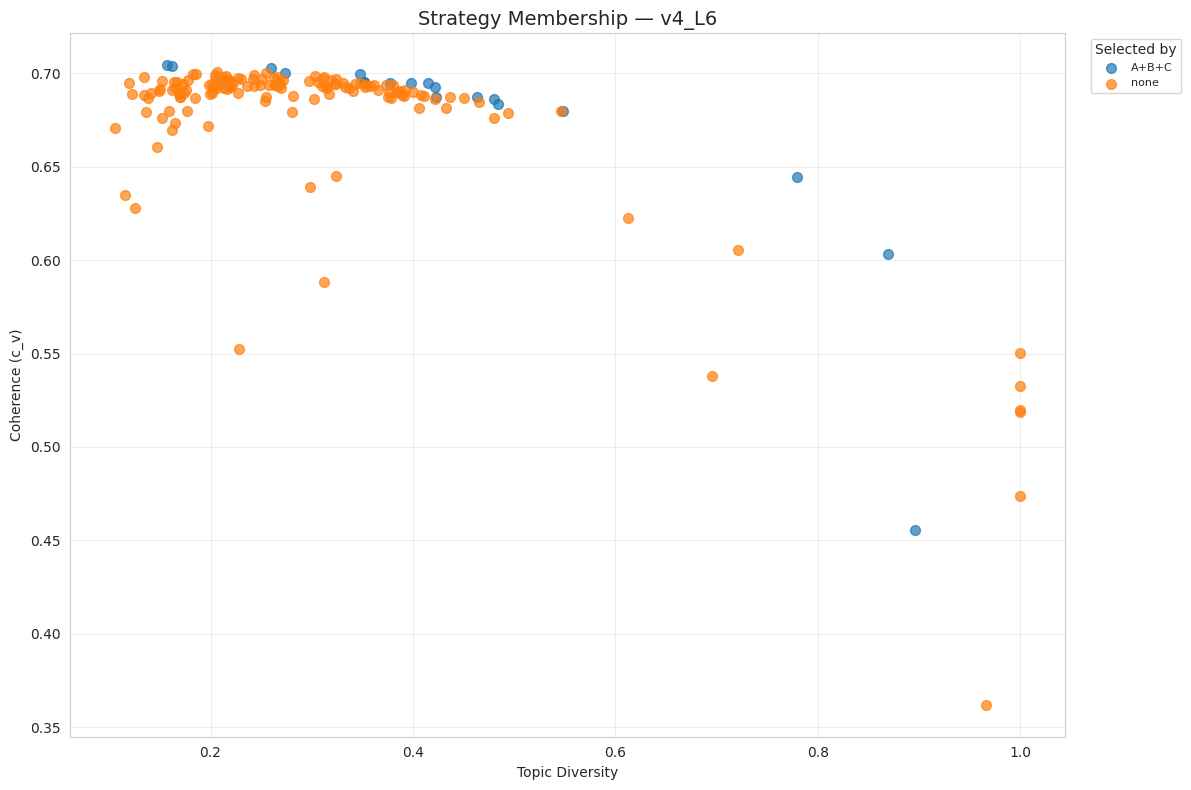


Cross-strategy comparison — v4_MPNet (v4_mpnet_granular_phase1_dryrun)
Top-k sizes: {'equal_weights': 17, 'coherence_priority': 17, 'eval_select': 17}
Union of all selected trials: 17


,strategy,compare_to,overlap_count
0,equal_weights,coherence_priority,17
1,equal_weights,eval_select,17
2,coherence_priority,equal_weights,17
3,coherence_priority,eval_select,17
4,eval_select,equal_weights,17
5,eval_select,coherence_priority,17


,strategy,top_k_count,trial_ids
0,equal_weights,17,v4_mpnet_granular_phase1_1_call_116;v4_mpnet_g...
1,coherence_priority,17,v4_mpnet_granular_phase1_1_call_116;v4_mpnet_g...
2,eval_select,17,v4_mpnet_granular_phase1_1_call_116;v4_mpnet_g...



equal_weights (A) — 17 selected trial(s)

coherence_priority (B) — 17 selected trial(s)

eval_select (C) — 17 selected trial(s)
Saved trial details: /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/v4_mpnet_granular_phase1_dryrun/notebook_analysis/tables/strategy_selected_trial_details.csv


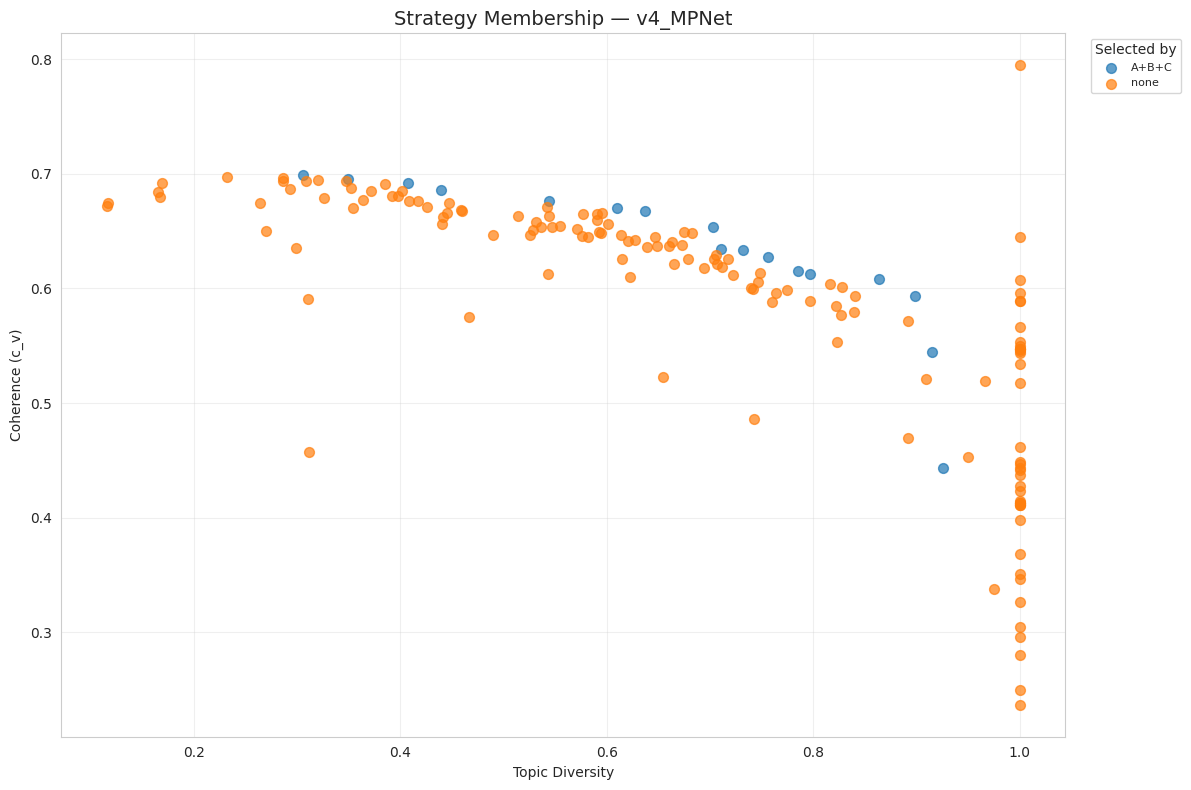

In [9]:
for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    run_tbl = run_dirs[rid]["tables_dir"]
    run_top = run_dirs[rid]["top_models_dir"]
    df_trials_run = filtered_by_run[rid]

    top_equal_run = top_equal_by_run[rid]
    top_priority_run = top_priority_by_run[rid]
    top_eval_run = top_eval_by_run[rid]

    sets = {
        "equal_weights": set(top_equal_run["trial_id"]),
        "coherence_priority": set(top_priority_run["trial_id"]),
        "eval_select": set(top_eval_run["trial_id"]),
    }

    rows = []
    for a in sets:
        for b in sets:
            if a != b:
                rows.append({"strategy": a, "compare_to": b, "overlap_count": len(sets[a] & sets[b])})
    overlap_df = pd.DataFrame(rows)
    overlap_df.to_csv(run_tbl / "strategy_pairwise_overlap.csv", index=False)

    summary_df = pd.DataFrame(
        [{"strategy": k, "top_k_count": len(v), "trial_ids": ";".join(sorted(v))} for k, v in sets.items()]
    )
    summary_df.to_csv(run_top / "strategy_overlap_summary.csv", index=False)

    print(f"\n{'=' * 60}\nCross-strategy comparison — {label} ({rid})\n{'=' * 60}")
    print("Top-k sizes:", {k: len(v) for k, v in sets.items()})
    print(f"Union of all selected trials: {len(set().union(*sets.values()))}")
    display(overlap_df)
    display(summary_df)

    _param_cols = (
        ["trial_id", "embedding_model", "coherence_c_v", "topic_diversity", "n_topics"]
        + list(nb_cfg["hyperparameters"])
        + [
            "n_topics_std", "n_topics_min", "n_topics_max", "n_topics_runs",
            "stability_score", "topic_stability_pass", "bo_objective", "seed", "bo_call",
        ]
    )
    param_cols = [c for c in _param_cols if c in df_trials_run.columns]

    _strategy_tops = [
        ("equal_weights (A)", top_equal_run, "Combined_Score"),
        ("coherence_priority (B)", top_priority_run, "Combined_Score"),
        ("eval_select (C)", top_eval_run, "weighted_score"),
    ]

    detail_parts = []
    for strategy_label, top_df, score_col in _strategy_tops:
        print(f"\n{strategy_label} — {len(top_df)} selected trial(s)")
        ordered_ids = [tid for tid in top_df["trial_id"].tolist() if tid in set(df_trials_run["trial_id"])]
        block = df_trials_run[df_trials_run["trial_id"].isin(ordered_ids)].copy()
        block["order_tmp"] = block["trial_id"].apply(lambda x: ordered_ids.index(x))
        block = block.sort_values("order_tmp").drop(columns="order_tmp")
        block = block[param_cols]
        block["strategy"] = strategy_label
        block["rank"] = range(1, len(block) + 1)
        if score_col in top_df.columns:
            score_map = dict(zip(top_df["trial_id"], top_df[score_col]))
            block["strategy_score"] = [score_map.get(tid) for tid in ordered_ids]
        detail_parts.append(block)

    selected_details = pd.concat(detail_parts, ignore_index=True)
    details_path = run_tbl / "strategy_selected_trial_details.csv"
    selected_details.to_csv(details_path, index=False)
    print(f"Saved trial details: {details_path}")

    plot_df = df_raw[df_raw["run_id"] == rid].copy()
    label_map = {}
    for tid in plot_df["trial_id"]:
        tags = [
            t for t, s in [("A", "equal_weights"), ("B", "coherence_priority"), ("C", "eval_select")]
            if tid in sets[s]
        ]
        label_map[tid] = "+".join(tags) if tags else "none"
    plot_df["selected_by"] = plot_df["trial_id"].map(label_map)

    fig, ax = plt.subplots(figsize=(12, 8))
    for memb, group in plot_df.groupby("selected_by"):
        ax.scatter(group["topic_diversity"], group["coherence_c_v"], label=memb, alpha=0.7, s=50)
    ax.set_title(f"Strategy Membership — {label}", fontsize=14)
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence (c_v)")
    ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left", title="Selected by")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(run_dirs[rid]["figures_dir"] / "strategy_membership_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9. Hyperparameter preview

Descriptive statistics (mean, std, min, max, quartiles) for configured BERTopic/HDBSCAN/UMAP/vectorizer hyperparameters within each strategy's top-**k** export.

In [10]:
hp_cols = nb_cfg["hyperparameters"]
preview_parts = []

for run in runs:
    rid = run["run_id"]
    label = run.get("label", rid)
    for name, df in [
        ("equal_weights", top_equal_by_run[rid]),
        ("coherence_priority", top_priority_by_run[rid]),
        ("eval_select", top_eval_by_run[rid]),
    ]:
        available = [c for c in hp_cols if c in df.columns]
        s = df[available].describe().T
        s["strategy"] = name
        s["run_id"] = rid
        s["model_label"] = label
        preview_parts.append(s.reset_index().rename(columns={"index": "hyperparameter"}))

preview = pd.concat(preview_parts, ignore_index=True)
for run in runs:
    rid = run["run_id"]
    sub = preview[preview["run_id"] == rid]
    sub.to_csv(run_dirs[rid]["tables_dir"] / "hyperparameter_descriptive_preview.csv", index=False)

if cmp_dirs and multi_run:
    preview.to_csv(cmp_dirs["tables_dir"] / "hyperparameter_descriptive_preview_all_runs.csv", index=False)

print(f"Hyperparameters configured: {len(hp_cols)} | preview rows: {len(preview)}")
display(preview.head(20))


Hyperparameters configured: 8 | preview rows: 63


,hyperparameter,count,mean,std,min,25%,50%,75%,max,strategy,run_id,model_label
0,bertopic__top_n_words,10.0,30.000000,9.451631,20.000000,23.500000,28.500000,33.500000,50.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
1,hdbscan__min_cluster_size,10.0,120.600000,66.578609,84.000000,96.500000,104.000000,104.000000,309.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
2,hdbscan__min_samples,10.0,24.800000,8.941787,12.000000,19.500000,25.500000,27.500000,40.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
3,umap__min_dist,10.0,0.030544,0.037390,0.002254,0.007111,0.011396,0.049575,0.116335,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
4,umap__n_components,10.0,10.300000,4.808557,5.000000,6.250000,9.000000,13.750000,20.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
5,umap__n_neighbors,10.0,9.200000,5.902918,5.000000,5.000000,5.500000,12.500000,22.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
6,vectorizer__min_df,10.0,10.600000,5.037636,3.000000,7.500000,10.000000,14.250000,19.000000,equal_weights,v4_l12_granular_phase1_dryrun,v4_L12
7,bertopic__top_n_words,10.0,30.000000,9.451631,20.000000,23.500000,28.500000,33.500000,50.000000,coherence_priority,v4_l12_granular_phase1_dryrun,v4_L12
8,hdbscan__min_cluster_size,10.0,120.600000,66.578609,84.000000,96.500000,104.000000,104.000000,309.000000,coherence_priority,v4_l12_granular_phase1_dryrun,v4_L12
9,hdbscan__min_samples,10.0,24.800000,8.941787,12.000000,19.500000,25.500000,27.500000,40.000000,coherence_priority,v4_l12_granular_phase1_dryrun,v4_L12


## 10. Pooled cross-embedding Pareto (full data, all runs)

Concatenate the **filtered** trials of all runs (~480 for the v4 three-way compare), min-max normalize coherence/diversity over the pooled range, and compute:

- **Global Pareto front** across embeddings (`Pareto_Efficient_All`) — candidates for the ultimate embedding + hyperparameter winner
- **Per-embedding fronts** (`Pareto_Efficient_PerModel`) for reference

The global front is ranked with the granular weighted objective. Outputs go to `comparison.base_dir` (`pooled_pareto_counts_by_run.csv`, `pooled_pareto_top_k.csv`, `pooled_pareto_overlay.png`).

Pooled trials: 381 | global Pareto front: 31


,model_label,n_filtered,n_global_pareto,n_per_model_pareto
0,v4_L12,115,9,10
1,v4_L6,154,17,19
2,v4_MPNet,112,5,17


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/pooled_pareto_top_k.csv


,model_label,bo_call,trial_id,coherence_c_v,topic_diversity,n_topics,outlier_rate,weighted_score
99,v4_L12,142,v4_l12_granular_phase1_1_call_142,0.624881,0.865546,357.0,0.701003,0.534205
51,v4_L12,79,v4_l12_granular_phase1_1_call_79,0.640600,0.822006,309.0,0.712030,0.531468
20,v4_L12,36,v4_l12_granular_phase1_1_call_36,0.610286,0.869081,359.0,0.690657,0.529379
14,v4_L12,26,v4_l12_granular_phase1_1_call_26,0.571845,0.941772,395.0,0.684879,0.527197
10,v4_L12,19,v4_l12_granular_phase1_1_call_19,0.648702,0.790698,301.0,0.729602,0.527095
0,v4_L12,0,v4_l12_granular_phase1_1_call_0,0.595833,0.898058,412.0,0.706520,0.527084
292,v4_MPNet,33,v4_mpnet_granular_phase1_1_call_33,0.593249,0.898964,386.0,0.725759,0.524179
126,v4_L6,15,v4_l6_granular_phase1_1_call_15,0.603146,0.869620,79.0,0.829395,0.512400
28,v4_L12,49,v4_l12_granular_phase1_1_call_49,0.653836,0.686327,373.0,0.692582,0.512233
45,v4_L12,73,v4_l12_granular_phase1_1_call_73,0.656654,0.668693,329.0,0.704805,0.508753


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/figures/pooled_pareto_overlay.png


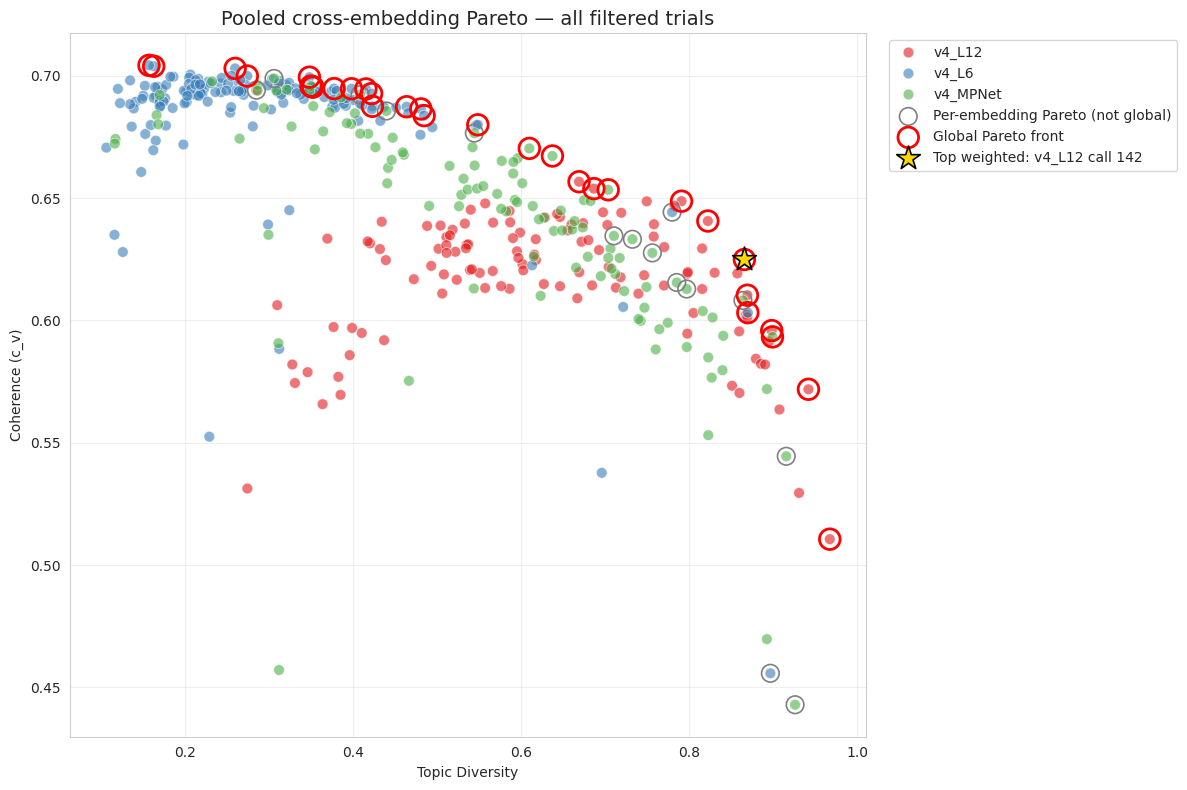

In [11]:
pooled_top = None
pooled_p = None

if multi_run and cmp_dirs:
    # Shared min-max axes across all runs so fronts are comparable between embeddings.
    pooled = normalize_for_pareto_pooled(df_trials.copy())
    pooled_p = pooled.rename(
        columns={
            "coherence_c_v_norm": "Coherence_norm",
            "topic_diversity_norm": "Topic_Diversity_norm",
            "embedding_model": "Embeddings_Model",
        }
    )
    pooled_p = analyze_pareto_efficiency(pooled_p, metrics=PARETO_METRICS, per_model=True)

    pooled_counts = (
        pooled_p.groupby("model_label")
        .agg(
            n_filtered=("trial_id", "count"),
            n_global_pareto=("Pareto_Efficient_All", "sum"),
            n_per_model_pareto=("Pareto_Efficient_PerModel", "sum"),
        )
        .reset_index()
    )
    counts_path = cmp_dirs["tables_dir"] / "pooled_pareto_counts_by_run.csv"
    pooled_counts.to_csv(counts_path, index=False)
    print(f"Pooled trials: {len(pooled_p)} | global Pareto front: {int(pooled_p['Pareto_Efficient_All'].sum())}")
    display(pooled_counts)

    global_front = pooled_p[pooled_p["Pareto_Efficient_All"]].copy()
    global_front = apply_weighted_score(
        global_front,
        float(weights["coherence"]),
        float(weights["diversity"]),
        float(weights["outlier"]),
        float(weights["stability"]),
        w_topic_count_floor=w_topic_floor,
    )
    global_front = global_front.sort_values("weighted_score", ascending=False)
    pooled_top = global_front.head(TOP_K)
    pooled_top_path = cmp_dirs["tables_dir"] / "pooled_pareto_top_k.csv"
    pooled_top.to_csv(pooled_top_path, index=False)
    print(f"Saved {pooled_top_path}")
    display(
        pooled_top[
            [c for c in ["model_label", "bo_call", "trial_id", "coherence_c_v", "topic_diversity", "n_topics", "outlier_rate", "weighted_score"] if c in pooled_top.columns]
        ].head(TOP_K)
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=pooled_p, x="topic_diversity", y="coherence_c_v", hue="model_label",
        palette="Set1", s=60, alpha=0.6, ax=ax,
    )
    per_model_front = pooled_p[pooled_p["Pareto_Efficient_PerModel"] & ~pooled_p["Pareto_Efficient_All"]]
    ax.scatter(
        per_model_front["topic_diversity"], per_model_front["coherence_c_v"],
        facecolors="none", edgecolors="gray", s=160, linewidths=1.2,
        label="Per-embedding Pareto (not global)", zorder=9,
    )
    ax.scatter(
        global_front["topic_diversity"], global_front["coherence_c_v"],
        facecolors="none", edgecolors="red", s=220, linewidths=2,
        label="Global Pareto front", zorder=10,
    )
    best = global_front.iloc[0]
    ax.scatter(
        best["topic_diversity"], best["coherence_c_v"],
        s=320, marker="*", color="gold", edgecolors="black", linewidths=1.2, zorder=12,
        label=f"Top weighted: {best['model_label']} call {int(best['bo_call'])}",
    )
    ax.set_title("Pooled cross-embedding Pareto — all filtered trials", fontsize=14)
    ax.set_xlabel("Topic Diversity")
    ax.set_ylabel("Coherence (c_v)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    overlay_path = cmp_dirs["figures_dir"] / "pooled_pareto_overlay.png"
    plt.savefig(overlay_path, dpi=150, bbox_inches="tight")
    print(f"Saved {overlay_path}")
    plt.show()
else:
    print("Single-run mode: skipping pooled cross-embedding Pareto section.")

## 11. Phase 2 Pareto refit merge (stability + compare-fit)

Merge the Phase 2 Pareto refit results (`{phase2_compare_dir}/comparison_summary.csv` + `stability_summary.csv`, from `run_v4_pareto_phase2.sh`) onto the Phase 1 BO trials by `bo_call`:

- **BO-reported vs compare-fit c_v** scatter, with refit-collapsed calls flagged (e.g. MPNet call 33, the Stage04 dry-run winner, collapses on refit)
- **Stable-only cross-embedding Pareto** on refit metrics (`stability_pass=True`, no collapse)
- **Three-way stable shortlist decision table** — the direct input for the cross-embedding winner pick

Outputs to `comparison.base_dir`: `phase2_merged_all_runs.csv`, `cross_embedding_stable_shortlist.csv`, `phase2_reported_vs_refit_cv.png`, `phase2_stable_pareto_overlay.png`. Skipped gracefully when Phase 2 artifacts are missing.

Phase 2 calls loaded: 46 across 3 run(s)
Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/phase2_merged_all_runs.csv


,model_label,n_phase2_calls,n_stable,n_collapsed
0,v4_L12,10,3,3
1,v4_L6,19,19,0
2,v4_MPNet,17,13,4


Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/figures/phase2_reported_vs_refit_cv.png


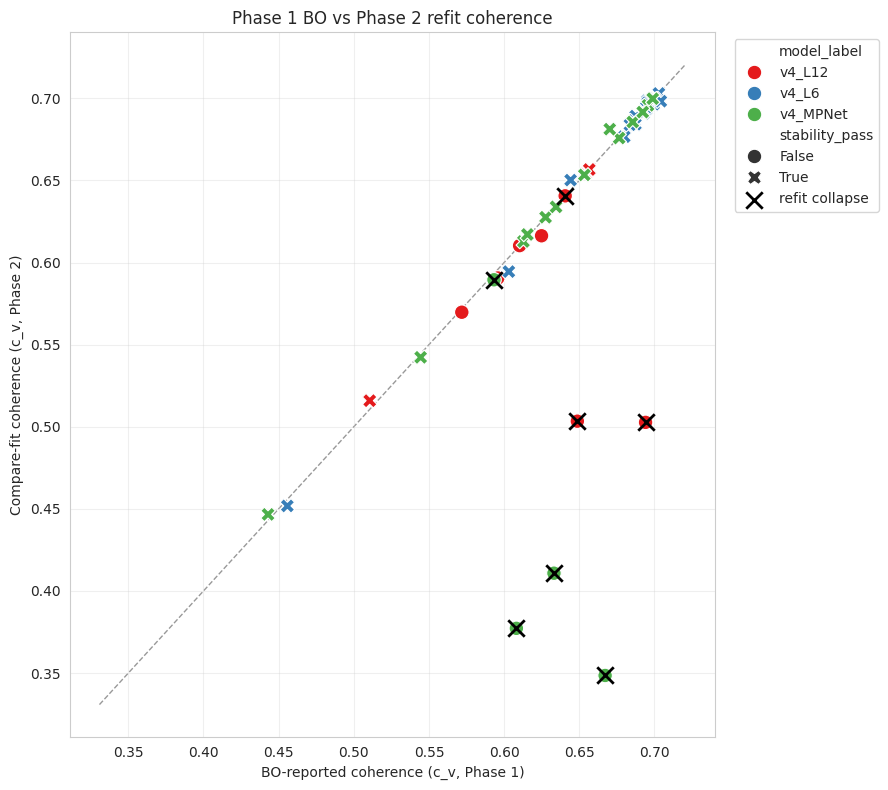

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/figures/phase2_stable_pareto_overlay.png


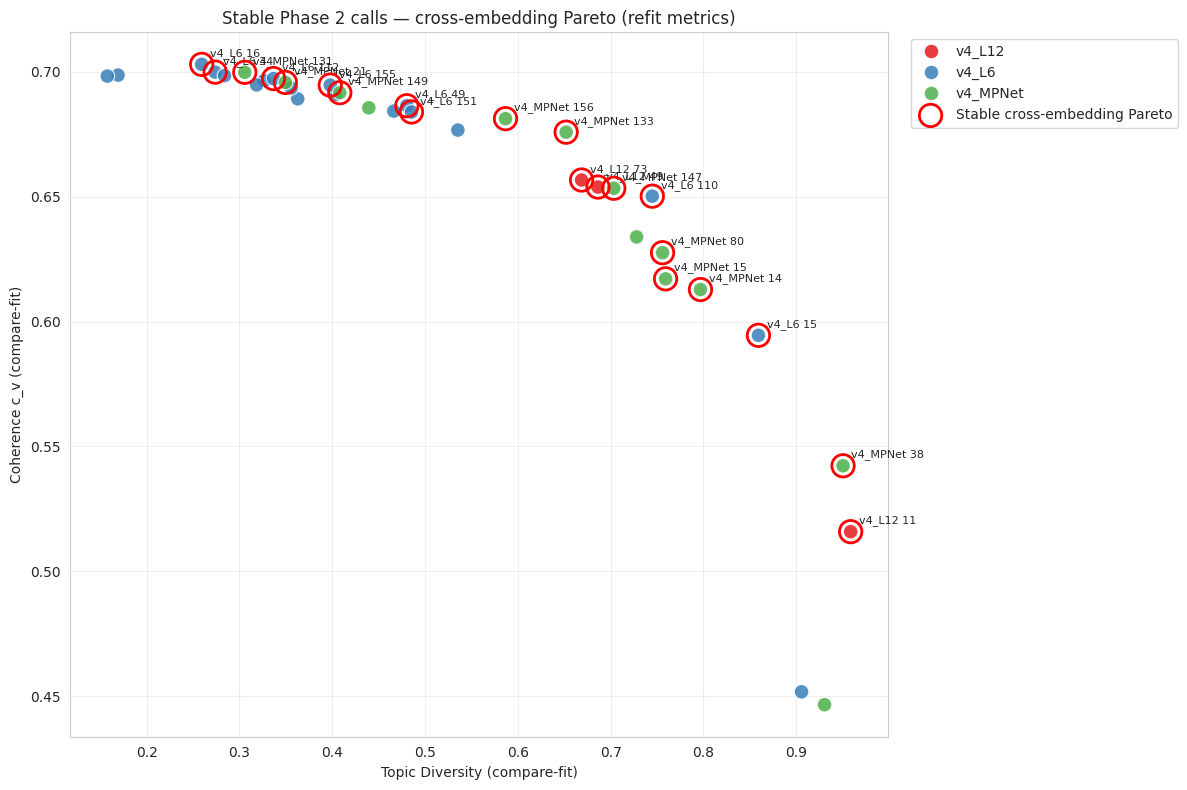

Saved /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/selection/_compare/v4_l12_l6_mpnet_pareto/tables/cross_embedding_stable_shortlist.csv


,model_label,bo_call,stable_pareto,refit_coherence_c_v,refit_topic_diversity,refit_n_topics,refit_n_topics_std
0,v4_L6,16,True,0.702955,0.259302,86,1.247219
1,v4_L6,34,True,0.699847,0.273810,84,2.357023
2,v4_MPNet,131,True,0.699769,0.305747,87,1.699673
3,v4_L6,9,False,0.698639,0.169231,91,1.247219
4,v4_L6,37,False,0.698450,0.283908,87,2.494438
5,v4_L6,138,False,0.698247,0.157647,85,4.082483
6,v4_L6,112,True,0.697264,0.336709,79,1.414214
7,v4_L6,20,False,0.696424,0.326667,90,2.054805
8,v4_MPNet,21,True,0.695719,0.349495,99,3.399346
9,v4_L6,38,False,0.694751,0.318557,97,1.699673


In [12]:
phase2 = load_phase2_results(runs, project_root)

if phase2.empty or cmp_dirs is None:
    print("No Phase 2 results configured/found (inputs.phase2_compare_dir): skipping section 11.")
else:
    # Attach BO-reported Phase 1 metrics + hyperparameters by (run_id, bo_call).
    bo_cols = (
        ["run_id", "bo_call", "trial_id", "coherence_c_v", "topic_diversity", "n_topics", "outlier_rate", "stability_score"]
        + [c for c in nb_cfg["hyperparameters"] if c in df_raw.columns]
    )
    bo_side = df_raw[[c for c in bo_cols if c in df_raw.columns]].rename(
        columns={
            "coherence_c_v": "bo_coherence_c_v",
            "topic_diversity": "bo_topic_diversity",
            "n_topics": "bo_n_topics",
            "outlier_rate": "bo_outlier_rate",
        }
    )
    phase2_merged = phase2.merge(bo_side, on=["run_id", "bo_call"], how="left")
    phase2_merged["stability_pass"] = phase2_merged["stability_pass"].fillna(False).astype(bool)
    phase2_merged["refit_collapse"] = phase2_merged["refit_collapse"].fillna(False).astype(bool)

    merged_path = cmp_dirs["tables_dir"] / "phase2_merged_all_runs.csv"
    phase2_merged.to_csv(merged_path, index=False)
    print(f"Phase 2 calls loaded: {len(phase2_merged)} across {phase2_merged['model_label'].nunique()} run(s)")
    print(f"Saved {merged_path}")

    stability_counts = (
        phase2_merged.groupby("model_label")
        .agg(
            n_phase2_calls=("bo_call", "count"),
            n_stable=("stability_pass", "sum"),
            n_collapsed=("refit_collapse", "sum"),
        )
        .reset_index()
    )
    display(stability_counts)

    # --- BO-reported vs compare-fit coherence ---
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.scatterplot(
        data=phase2_merged, x="bo_coherence_c_v", y="refit_coherence_c_v",
        hue="model_label", style="stability_pass", palette="Set1", s=110, ax=ax,
    )
    collapsed = phase2_merged[phase2_merged["refit_collapse"]]
    if len(collapsed):
        ax.scatter(
            collapsed["bo_coherence_c_v"], collapsed["refit_coherence_c_v"],
            marker="x", color="black", s=140, linewidths=2, zorder=11, label="refit collapse",
        )
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, color="0.6", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlabel("BO-reported coherence (c_v, Phase 1)")
    ax.set_ylabel("Compare-fit coherence (c_v, Phase 2)")
    ax.set_title("Phase 1 BO vs Phase 2 refit coherence")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    cv_fig_path = cmp_dirs["figures_dir"] / "phase2_reported_vs_refit_cv.png"
    plt.savefig(cv_fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved {cv_fig_path}")
    plt.show()

    # --- Stable-only cross-embedding Pareto on refit metrics ---
    stable = phase2_merged[phase2_merged["stability_pass"] & ~phase2_merged["refit_collapse"]].copy()
    if stable.empty:
        print("No stable Phase 2 calls: skipping stable Pareto + shortlist.")
    else:
        # Pareto dominance is invariant to monotonic scaling, so raw refit metrics suffice.
        stable["stable_pareto"] = identify_pareto(
            stable, ["refit_coherence_c_v", "refit_topic_diversity"]
        )

        fig, ax = plt.subplots(figsize=(12, 8))
        sns.scatterplot(
            data=stable, x="refit_topic_diversity", y="refit_coherence_c_v",
            hue="model_label", palette="Set1", s=110, alpha=0.85, ax=ax,
        )
        front = stable[stable["stable_pareto"]]
        ax.scatter(
            front["refit_topic_diversity"], front["refit_coherence_c_v"],
            facecolors="none", edgecolors="red", s=260, linewidths=2,
            label="Stable cross-embedding Pareto", zorder=10,
        )
        for _, row in front.iterrows():
            ax.annotate(
                f"{row['model_label']} {int(row['bo_call'])}",
                (row["refit_topic_diversity"], row["refit_coherence_c_v"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8,
            )
        ax.set_title("Stable Phase 2 calls — cross-embedding Pareto (refit metrics)")
        ax.set_xlabel("Topic Diversity (compare-fit)")
        ax.set_ylabel("Coherence c_v (compare-fit)")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        stable_fig_path = cmp_dirs["figures_dir"] / "phase2_stable_pareto_overlay.png"
        plt.savefig(stable_fig_path, dpi=150, bbox_inches="tight")
        print(f"Saved {stable_fig_path}")
        plt.show()

        # --- Three-way stable shortlist decision table ---
        shortlist_cols = [
            c
            for c in [
                "model_label", "run_id", "bo_call", "stable_pareto",
                "refit_coherence_c_v", "refit_topic_diversity", "refit_n_topics",
                "refit_n_topics_std", "refit_outlier_rate",
                "bo_coherence_c_v", "bo_topic_diversity", "bo_n_topics",
            ]
            + list(nb_cfg["hyperparameters"])
            if c in stable.columns
        ]
        shortlist = (
            stable[shortlist_cols]
            .sort_values("refit_coherence_c_v", ascending=False)
            .reset_index(drop=True)
        )
        shortlist_path = cmp_dirs["tables_dir"] / "cross_embedding_stable_shortlist.csv"
        shortlist.to_csv(shortlist_path, index=False)
        print(f"Saved {shortlist_path}")
        display(
            shortlist[
                [c for c in ["model_label", "bo_call", "stable_pareto", "refit_coherence_c_v", "refit_topic_diversity", "refit_n_topics", "refit_n_topics_std"] if c in shortlist.columns]
            ]
        )